# ETS MARL — Q-Learning Baseline

This notebook trains and analyses a **tabular Q-learning** baseline for the EU ETS multi-agent environment, and compares it against the default-config PPO/HAPPO sweep — the comparison is the headline contribution of this notebook to **Sub-RQ 1 (simulation credibility)**.

The Q-learning agents use:
- **State discretisation**: 5 features × 3 bins = 243 discrete states
- **Action profiles**: 6 auction × 4 secondary = 24 predefined strategy templates
- **Standard Q-learning**: $\alpha=0.1$, $\gamma=0.95$, linear $\varepsilon$-decay

Crucially, the baseline trains in the **same `ETSEnvironment`** as the PPO trainer — same warm-start, same uniform-price auction, same MSR / penalty / ESG mechanisms — so reward, clearing price, compliance rate, and the anchor-invariant `quality_score` are directly comparable.

**Notebook layout.** §1–§5 setup and training. §6–§8 standalone Q-learning analysis (training curves, Q-table inspection, strategy-frequency). §9 greedy evaluation. §10 single-seed Q-learning vs PPO overlay. §11 **cross-seed default-sweep comparison (Sub-RQ 1)**. §13 summary tables and Sub-RQ 1 takeaways and takeaways.


In [2]:
# Install notebook dependencies if needed.
# Set INSTALL_NOTEBOOK_DEPS = True (or run the cell with required packages missing)
# to pip-install everything in notebooks/requirements-notebooks.txt using the
# CURRENT kernel's interpreter. This is more reliable than `%pip install -r {path}`
# (IPython magics don't expand `{var}` at runtime) and works on Azure / Colab / local.
import subprocess, sys, importlib, re
from pathlib import Path

INSTALL_NOTEBOOK_DEPS = False  # flip to True to force-reinstall

# Map PyPI distribution name -> import module name when they differ.
_DIST_TO_IMPORT = {
    "pyyaml": "yaml",
    "scikit-learn": "sklearn",
    "imbalanced-learn": "imblearn",
    "opencv-python": "cv2",
    "pillow": "PIL",
    "beautifulsoup4": "bs4",
    "ipython": "IPython",
}

def _find_requirements():
    req_name = "requirements-notebooks.txt"
    here = Path.cwd()
    candidates = [here / req_name, here / "notebooks" / req_name]
    candidates.extend(p / "notebooks" / req_name for p in here.parents)
    return next((p for p in candidates if p.exists()), None)

def _parse_requirements(req_path):
    """Extract distribution names from a requirements file (skip comments, options, env markers)."""
    dists = []
    for raw in req_path.read_text(encoding="utf-8").splitlines():
        line = raw.strip()
        if not line or line.startswith("#") or line.startswith("-"):
            continue
        # Strip env markers and extras: "pkg[extra]>=1.0; python_version>='3.9'"
        line = line.split(";", 1)[0].strip()
        m = re.match(r"^([A-Za-z0-9_.\-]+)", line)
        if m:
            dists.append(m.group(1).lower())
    return dists

def _missing_required(dists):
    missing = []
    for dist in dists:
        mod = _DIST_TO_IMPORT.get(dist, dist.replace("-", "_"))
        try:
            importlib.import_module(mod)
        except ImportError:
            missing.append(dist)
    return missing

req_path = _find_requirements()
if req_path is None:
    raise FileNotFoundError("Could not find notebooks/requirements-notebooks.txt")

dists = _parse_requirements(req_path)
missing = _missing_required(dists)

if INSTALL_NOTEBOOK_DEPS or missing:
    if missing:
        print(f"Missing packages: {missing}")
    print(f"Installing notebook dependencies from: {req_path}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", str(req_path)])
else:
    print(f"All {len(dists)} notebook dependencies present; skipping install.")
    print("(Set INSTALL_NOTEBOOK_DEPS = True to force a reinstall.)")


All 14 notebook dependencies present; skipping install.
(Set INSTALL_NOTEBOOK_DEPS = True to force a reinstall.)


## 1. Setup

In [3]:
import os, sys

# Navigate to project root
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, os.getcwd())

print(f'Working directory: {os.getcwd()}')

Working directory: c:\Users\danie\Documents\Python_Scripts\Master Thesis\Thesis-Energy-Auction


In [4]:
import numpy as np
import pandas as pd
from src.utils.run_data import load_run_csv, glob_run_logs  # parquet-cached log loader
import matplotlib.pyplot as plt
import yaml
import tqdm
import time

from src.environment.ets_environment import ETSEnvironment
from src.agents.q_learning_agent import QLearningAgent, StateDiscretizer, ActionProfileMapper
from src.train_qlearning import train_qlearning, evaluate_qlearning, merge_configs
from src.analysis.qlearning_analysis import (
    plot_qtable_heatmaps, plot_secondary_heatmaps,
    plot_strategy_frequency, plot_reward_comparison,
    plot_price_comparison, plot_green_comparison,
    plot_compliance_comparison, load_training_log
)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (12, 5)

print('All imports successful.')

All imports successful.


## 2. Load Configuration

In [11]:
with open('configs/default.yaml') as f:
    base_config = yaml.safe_load(f)

with open('configs/qlearning.yaml') as f:
    ql_config = yaml.safe_load(f)

config = merge_configs(base_config, ql_config)

n_agents = config['companies']['n_agents']
n_years = config['simulation']['n_years']
ql_params = config['qlearning']

print(f'Agents: {n_agents} learning + {config["companies"].get("n_bot_agents", 0)} bots')
print(f'Episode length: {n_years} years')
print(f'Q-learning: {ql_params["n_episodes"]} episodes, '
      f'alpha={ql_params["alpha"]}, gamma={ql_params["gamma"]}')
print(f'Epsilon: {ql_params["epsilon_start"]} -> {ql_params["epsilon_end"]} '
      f'over {ql_params["epsilon_decay_frac"]*100:.0f}% of training')
print(f'Reward shaping: beta={config["reward"]["shaping_beta"]}, '
      f'gamma={config["reward"]["shaping_gamma"]} '
      f'(same reward structure as PPO)')

Agents: 8 learning + 0 bots
Episode length: 12 years
Q-learning: 10000 episodes, alpha=0.1, gamma=0.95
Epsilon: 1.0 -> 0.05 over 70% of training
Reward shaping: beta=7.0, gamma=1.0 (same reward structure as PPO)


## 3. Explore the State/Action Space

Before training, let's understand how the discretizer and action profiles work.

In [5]:
# Show state space structure
disc = StateDiscretizer()
print(f'Total discrete states: {disc.N_STATES}')
print(f'Features and bin edges:')
for name, edges in disc._BINS.items():
    print(f'  {name:10s}: low <= {edges[0]:.2f} | mid <= {edges[1]:.2f} | high')

print(f'\nAction profiles:')
mapper = ActionProfileMapper()
print(f'  Auction ({mapper.N_AUCTION_PROFILES}): {mapper.auction_profile_names()}')
print(f'  Secondary ({mapper.N_SECONDARY_PROFILES}): {mapper.secondary_profile_names()}')
print(f'  Total action combinations: {mapper.N_AUCTION_PROFILES * mapper.N_SECONDARY_PROFILES}')

Total discrete states: 243
Features and bin edges:
  time      : low <= 0.33 | mid <= 0.67 | high
  price     : low <= 0.30 | mid <= 0.55 | high
  green     : low <= 0.35 | mid <= 0.65 | high
  gap       : low <= 0.10 | mid <= 0.60 | high
  cf        : low <= 0.01 | mid <= 0.20 | high

Action profiles:
  Auction (6): ['Conservative', 'Moderate', 'Aggressive', 'GreenPush', 'Financial', 'PanicBuy']
  Secondary (4): ['Hold', 'SellSurplus', 'BuyShortfall', 'AggressiveBuy']
  Total action combinations: 24


In [6]:
# Show what each auction profile produces at a reference price
env_temp = ETSEnvironment(config, seed=42)
env_temp.reset(seed=42)

ref_price = 80.0  # reference MA3 price
company = env_temp.companies[0]  # coal-heavy agent

print(f'Auction profiles at MA3 price = {ref_price} EUR/t (Agent A1: coal-heavy):')
print(f'{"Profile":<15s} {"Bid":>7s} {"Qty":>5s} {"Inv%":>5s} {"Tech":>10s}')
print('-' * 45)
for p_idx in range(6):
    action = mapper.get_auction_action(p_idx, company, ref_price, config)
    tech_idx = np.argmax(action[3:6])
    tech_names = ['onshore', 'offshore', 'solar']
    name = mapper.auction_profile_names()[p_idx]
    print(f'{name:<15s} {action[0]:7.1f} {action[1]:5.2f} {action[2]*100:5.1f} {tech_names[tech_idx]:>10s}')

Market calibration: 8 participants, emissions=20.7 Mt, cap=22.8 Mt
[ETSEnvironment] 8 learning + 0 bot = 8 total agents | cancel_under_subscribed=False
[ETSEnvironment] Initial bank seed example (episode-start allowance holdings, unit: MtCO2 allowances): A1=1.83, A2=1.75, A3=1.64, A4=1.53, A5=0.99, A6=1.22, A7=0.77, A8=0.85
[ETSEnvironment] Context: this is each active agent's starting bank before year-1 actions/compliance; total TNAC seed=10.59 MtCO2.
Auction profiles at MA3 price = 80.0 EUR/t (Agent A1: coal-heavy):
Profile             Bid   Qty  Inv%       Tech
---------------------------------------------
Conservative       72.0  1.00   1.0      solar
Moderate           88.0  1.00   3.0      solar
Aggressive        104.0  1.50   6.0    onshore
GreenPush          96.0  1.00  20.0    onshore
Financial          64.0  0.70   0.0      solar
PanicBuy          166.5  2.00   3.0      solar


## 4. Run a Random-Policy Episode (Pre-training Baseline)

In [7]:
# Run one episode with fully random actions to establish a floor
env = ETSEnvironment(config, seed=42)
agents_random = [QLearningAgent(i, seed=42+i) for i in range(n_agents)]

obs1, _ = env.reset(seed=42)
total_rewards = np.zeros(n_agents)
prices, green_fracs = [], []

for year in range(n_years):
    price_ma3 = env._compute_price_ma3()
    
    # Phase 1 (random)
    auction_actions = np.zeros((n_agents, 6), dtype=np.float32)
    a1_indices = np.zeros(n_agents, dtype=int)
    for i in range(n_agents):
        action, a1_idx = agents_random[i].select_auction_action(
            obs1[i], env.companies[i], price_ma3, config, epsilon=1.0)
        auction_actions[i] = action
        a1_indices[i] = a1_idx
    
    obs2, _ = env.step_auction(auction_actions)
    
    # Phase 2 (random)
    sec_actions = np.zeros((n_agents, 2), dtype=np.float32)
    for i in range(n_agents):
        action, _ = agents_random[i].select_secondary_action(
            obs2[i], env.companies[i], env._phase1_clearing_price,
            config, a1_idx=a1_indices[i], epsilon=1.0)
        sec_actions[i] = action
    
    obs1, rewards, terminated, _, info = env.step_secondary(sec_actions)
    total_rewards += rewards
    
    yl = info.get('year_log', {})
    prices.append(yl.get('clearing_price', 0))
    green_fracs.append([env.companies[i].green_frac for i in range(n_agents)])

print('Random policy episode results:')
print(f'  Total rewards: {["{:.2f}".format(r) for r in total_rewards]}')
print(f'  Final green fracs: {["{:.1f}%".format(env.companies[i].green_frac*100) for i in range(n_agents)]}')
print(f'  Price range: {min(prices):.1f} - {max(prices):.1f} EUR/t')

Market calibration: 8 participants, emissions=20.7 Mt, cap=22.8 Mt
[ETSEnvironment] 8 learning + 0 bot = 8 total agents | cancel_under_subscribed=False
[ETSEnvironment] Initial bank seed example (episode-start allowance holdings, unit: MtCO2 allowances): A1=1.83, A2=1.75, A3=1.64, A4=1.53, A5=0.99, A6=1.22, A7=0.77, A8=0.85
[ETSEnvironment] Context: this is each active agent's starting bank before year-1 actions/compliance; total TNAC seed=10.59 MtCO2.
Random policy episode results:
  Total rewards: ['-2.86', '4.23', '1.97', '3.30', '-18.21', '1.48', '-2.91', '6.22']
  Final green fracs: ['58.8%', '71.9%', '75.1%', '72.8%', '82.1%', '91.4%', '94.7%', '100.0%']
  Price range: 45.0 - 166.5 EUR/t


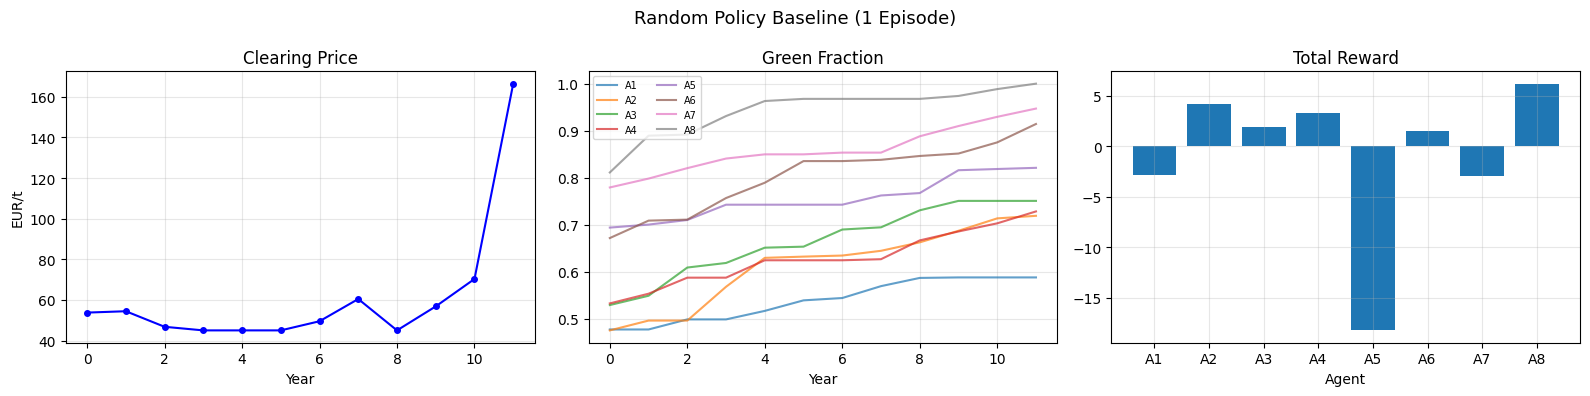

In [8]:
# Plot random episode
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(prices, 'b-o', markersize=4)
axes[0].set_title('Clearing Price')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('EUR/t')
axes[0].grid(True, alpha=0.3)

green_arr = np.array(green_fracs)
for i in range(n_agents):
    axes[1].plot(green_arr[:, i], label=f'A{i+1}', alpha=0.7)
axes[1].set_title('Green Fraction')
axes[1].set_xlabel('Year')
axes[1].legend(fontsize=7, ncol=2)
axes[1].grid(True, alpha=0.3)

axes[2].bar(range(n_agents), total_rewards)
axes[2].set_title('Total Reward')
axes[2].set_xlabel('Agent')
axes[2].set_xticks(range(n_agents))
axes[2].set_xticklabels([f'A{i+1}' for i in range(n_agents)])
axes[2].grid(True, alpha=0.3)

plt.suptitle('Random Policy Baseline (1 Episode)', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Train Q-Learning Agents

Train for 5,000 episodes (adjustable via config). This should take a few minutes.

In [13]:
SEEDS = [1729, 8191, 6561, 5041]

# Run training
for seed in tqdm.tqdm(SEEDS, desc='Training Q-learning agents'):
    trained_agents, trained_config = train_qlearning(base_config, ql_config, seed=seed)

Training Q-learning agents:   0%|          | 0/4 [00:00<?, ?it/s]


══════════════════════════════════════════════════════════════════════
  Q-Learning Baseline Training — seed 1729
  Episodes: 10000  |  Alpha: 0.1  |  Gamma: 0.95
  Epsilon: 1.00 → 0.05 over 7000 episodes
  Learning agents: 8  |  Bots: 0  |  Years/episode: 12
  States: 243  |  Actions: 6×4 profiles
  Console log every 100 episodes
══════════════════════════════════════════════════════════════════════
  Console legend (HAPPO-mirrored, per log_interval episode):
  │  Ep / elapsed / ETA   Episode number · wall-clock · estimated remaining
  │  ε                    Current epsilon-greedy exploration rate
  │  Q                    Anchor-invariant quality_score in [-5, +5]
  │  Price/yr             Auction clearing price per simulated year (€/t)
  │  Emiss/yr             Total system emissions per year (Mt)
  │  Bid/yr               Total agent bid demand per year (Mt)
  │  Auct/yr              Auction supply after cap+rollover+MSR (Mt)
  │  Per-agent table:
  │     Green             Green 

Training Q-learning agents:  25%|██▌       | 1/4 [21:46<1:05:20, 1306.69s/it]

═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  Ep 10000/10000 │ 0:21:47 elapsed  ETA 0:00:00  (0.13 s/ep) │ ε=0.050 │ Q=+1.74
  Price/yr:    60    51    48    48    45    45    45    54    58    68    66    83   (σ=11)  ↑
  Emiss/yr:  18.3  13.3  15.6  14.3  14.3  12.9  12.0  12.2  11.4  10.1   9.7   8.3   (avg 12.7 Mt/yr)  ↓
  Bid/yr  :  19.1  17.9  15.0  14.6  17.5  15.1  13.9  13.9  13.7  13.8  12.8  11.9   (agents' total auction demand, Mt)  ↓
  Auct/yr :  22.8  21.8  20.8  16.0  15.2  14.0  12.8  11.6  10.3   9.5   8.7   7.9   (auction supply after cap+rollover+MSR, TNAC=15.3 Mt)  ↓
  Health: comply=99%  green(learning avg)=81% │ Sec: 21.7Mt  match=83%  avg=79€
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Training Q-learning agents:  50%|█████     | 2/4 [44:49<45:02, 1351.38s/it]  

═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  Ep 10000/10000 │ 0:23:03 elapsed  ETA 0:00:00  (0.14 s/ep) │ ε=0.050 │ Q=+1.60
  Price/yr:    60    51    48    45    45    45    54    58    63    76    85    97   (σ=16)  ↑
  Emiss/yr:  17.1  15.2  14.8  14.7  15.2  14.3  11.5  10.4  10.5   9.8   8.6   7.6   (avg 12.5 Mt/yr)  ↓
  Bid/yr  :  19.3  16.6  15.3  14.4  15.8  18.0  16.8  12.3  13.1  15.8  14.4  13.5   (agents' total auction demand, Mt)  ↓
  Auct/yr :  22.8  21.8  19.8  17.3  15.8  15.1  13.5  11.9  10.5   9.1   8.1   7.0   (auction supply after cap+rollover+MSR, TNAC=19.2 Mt)  ↓
  Health: comply=98%  green(learning avg)=83% │ Sec: 15.0Mt  match=67%  avg=83€
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Training Q-learning agents:  75%|███████▌  | 3/4 [1:07:03<22:23, 1343.61s/it]

═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  Ep 10000/10000 │ 0:22:14 elapsed  ETA 0:00:00  (0.13 s/ep) │ ε=0.050 │ Q=+1.24
  Price/yr:    54    54    47    45    54    45    53    55    56    71    73    80   (σ=11)  ↑
  Emiss/yr:  15.0  15.2  16.5  15.0  13.9  14.1  15.3  12.4  12.1   9.8  10.9   9.4   (avg 13.3 Mt/yr)  ↓
  Bid/yr  :  21.1  17.6  14.9  15.0  18.4  16.4  14.9  14.1  12.5  16.1  13.6  12.6   (agents' total auction demand, Mt)  ↓
  Auct/yr :  22.8  21.8  16.8  15.2  14.6  13.5  12.4  11.6  11.8  11.7  10.9   8.1   (auction supply after cap+rollover+MSR, TNAC=16.1 Mt)  ↓
  Health: comply=98%  green(learning avg)=82% │ Sec: 21.5Mt  match=83%  avg=73€
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Training Q-learning agents: 100%|██████████| 4/4 [1:29:37<00:00, 1344.35s/it]

═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  Ep 10000/10000 │ 0:22:34 elapsed  ETA 0:00:00  (0.14 s/ep) │ ε=0.050 │ Q=+1.70
  Price/yr:    60    51    48    45    62    57    66    80    88   101   117   132   (σ=27)  ↑
  Emiss/yr:  15.6  15.1  15.5  14.0  11.7  12.0  10.4  11.3  10.3  10.9   9.5   8.2   (avg 12.0 Mt/yr)  ↓
  Bid/yr  :  18.7  16.5  15.8  15.4  19.0  15.3  15.6  15.6  16.1  12.4  12.9  12.0   (agents' total auction demand, Mt)  ↓
  Auct/yr :  22.8  21.8  19.0  16.6  15.1  13.8  12.0  10.5   9.2   8.3   7.6   7.2   (auction supply after cap+rollover+MSR, TNAC=17.8 Mt)  ↓
  Health: comply=97%  green(learning avg)=81% │ Sec: 18.7Mt  match=83%  avg=90€
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

## 6. Training Curves

In [9]:
import glob
import re

# Resolve results directory even if Section 5 was run on another device
if 'trained_config' in globals() and isinstance(trained_config, dict):
    results_dir = trained_config.get('logging', {}).get('results_dir', 'results/qlearning/')
else:
    results_dir = 'results/qlearning/'

# Find training logs; prefer the current SEED if available.
# Use glob_run_logs so parquet-only runs (post end-of-run compression) are found.
log_pattern = os.path.join(results_dir, 'ql_training_log_s*.csv')
log_candidates = glob_run_logs(log_pattern)

if not log_candidates:
    # Fallback: search recursively under results/
    log_candidates = glob_run_logs(os.path.join('results', '**', 'ql_training_log_s*.csv'), recursive=True)

if not log_candidates:
    raise FileNotFoundError(
        "No Q-learning training log found. Expected files like 'ql_training_log_s42.csv' "
        "or their parquet siblings under results/qlearning/."
    )

def _seed_from_path(path):
    m = re.search(r'ql_training_log_s(\d+)\.(?:csv|parquet)$', path.replace('\\', '/'))
    return int(m.group(1)) if m else -1

preferred_seed = globals().get('SEED', None)
if preferred_seed is not None:
    matching = [p for p in log_candidates if _seed_from_path(p) == preferred_seed]
else:
    matching = []

if matching:
    log_path = matching[0]
else:
    # Use latest modified log if preferred seed is unavailable
    log_path = max(log_candidates, key=os.path.getmtime)

ACTIVE_SEED = _seed_from_path(log_path)
SEED = ACTIVE_SEED  # keep downstream cells consistent
results_dir = os.path.dirname(log_path) or results_dir

ql_df = load_run_csv(log_path)

print(f'Training log loaded: {log_path}')
print(f'Active seed: {ACTIVE_SEED}')
print(f'Training log: {len(ql_df)} episodes')
print(f'Columns: {list(ql_df.columns)[:10]}...')

# Optional artifact: Q-tables
qtable_candidates = []
qtable_pref = os.path.join(results_dir, f'qtables_s{ACTIVE_SEED}_final.npz')
if os.path.exists(qtable_pref):
    qtable_candidates = [qtable_pref]
else:
    qtable_candidates = glob.glob(os.path.join(results_dir, 'qtables_s*_final.npz'))

HAS_QTABLES = len(qtable_candidates) > 0
qtables = None
qtable_path = None
if HAS_QTABLES:
    qtable_path = qtable_candidates[0]
    qtables = dict(np.load(qtable_path, allow_pickle=False))
    print(f'Q-tables loaded: {qtable_path}')
else:
    print('Q-tables not found. Q-table analysis and evaluation cells will be skipped.')

# Build evaluation inputs if possible
EVAL_AGENTS = None
EVAL_CONFIG = None

if 'trained_agents' in globals() and 'trained_config' in globals():
    EVAL_AGENTS = trained_agents
    EVAL_CONFIG = trained_config
    print('Evaluation source: in-memory trained_agents/trained_config')
else:
    # Rebuild config from YAML (works when notebook restarted on another machine)
    if 'config' not in globals():
        with open('configs/default.yaml') as f:
            _base = yaml.safe_load(f)
        with open('configs/qlearning.yaml') as f:
            _ql = yaml.safe_load(f)
        config = merge_configs(_base, _ql)
    EVAL_CONFIG = config

    if HAS_QTABLES:
        n_agents_local = EVAL_CONFIG['companies']['n_agents']
        ql_params_local = EVAL_CONFIG.get('qlearning', {})
        restored_agents = [
            QLearningAgent(
                i,
                alpha=ql_params_local.get('alpha', 0.1),
                gamma=ql_params_local.get('gamma', 0.95),
                seed=ACTIVE_SEED + i,
            )
            for i in range(n_agents_local)
        ]
        for i in range(n_agents_local):
            key = f'agent_{i}'
            if key in qtables:
                restored_agents[i].q_table = qtables[key]
        EVAL_AGENTS = restored_agents
        print('Evaluation source: agents reconstructed from saved Q-tables + YAML config')

ql_df.tail(3)


Training log loaded: results/qlearning\ql_training_log_s8191.parquet
Active seed: 8191
Training log: 10000 episodes
Columns: ['episode', 'epsilon', 'clearing_price_last', 'cap_last', 'tnac', 'ep_mean_clearing_price', 'mean_price', 'secondary_volume', 'secondary_avg_price', 'price_start']...
Q-tables loaded: results/qlearning\qtables_s8191_final.npz
Evaluation source: agents reconstructed from saved Q-tables + YAML config


,episode,epsilon,clearing_price_last,cap_last,tnac,ep_mean_clearing_price,mean_price,secondary_volume,secondary_avg_price,price_start,...,green_frac_A8,delta_green_A8,compliance_rate_A8,shortfall_A8,penalty_A8,bid_price_A8,queue_size_A8,a1_profile_A8,a2_profile_A8,invest_cost_A8
9997,9997,0.05,193.070007,11.7943,17.188000,67.029999,67.029999,17.5886,88.180000,60.48,...,1.0000,0.0,1.000,0.0000,0.000,193.070007,3,5,0,1271.036011
9998,9998,0.05,118.809998,11.7943,19.443399,72.889999,72.889999,14.5300,78.860001,60.48,...,0.9841,0.0,0.917,0.1015,17.077,118.809998,6,5,0,1418.635986
9999,9999,0.05,96.620003,11.7943,19.249100,60.450001,60.450001,15.0000,82.970001,60.48,...,1.0000,0.0,1.000,0.0000,0.000,96.620003,5,2,2,1215.588989


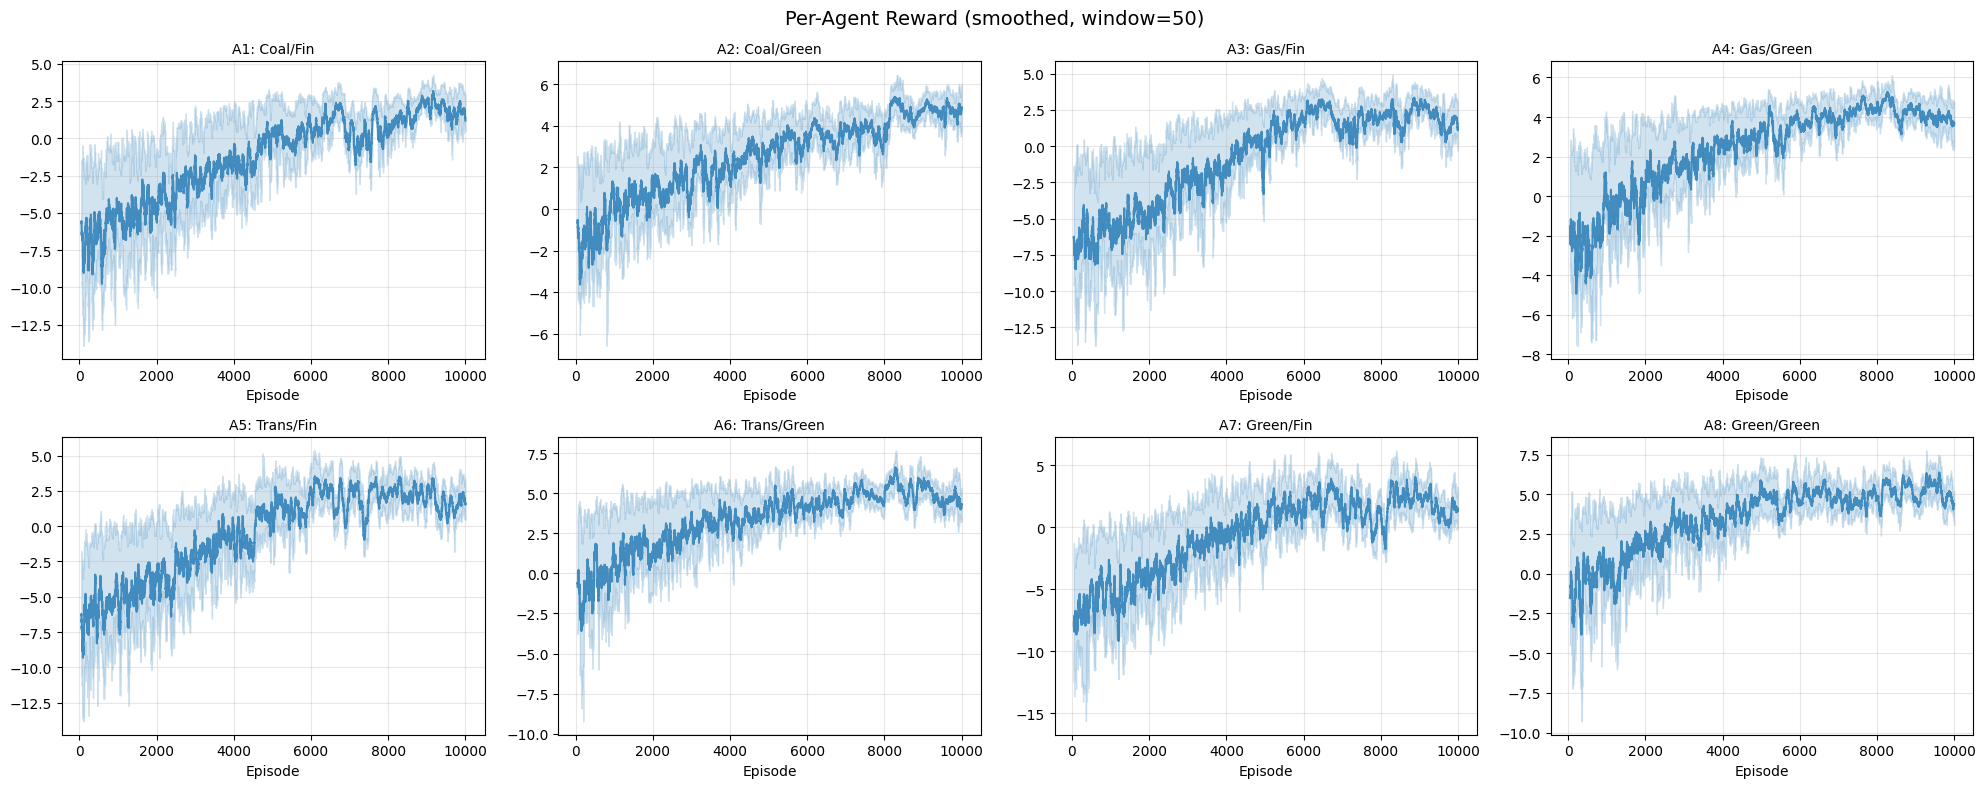

In [12]:
# Reward curves
window = 50
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle(f'Per-Agent Reward (smoothed, window={window})', fontsize=14)

archetypes = ['Coal/Fin', 'Coal/Green', 'Gas/Fin', 'Gas/Green',
              'Trans/Fin', 'Trans/Green', 'Green/Fin', 'Green/Green']

for i in range(n_agents):
    ax = axes[i // 4, i % 4]
    col = f'reward_A{i+1}'
    rewards = ql_df[col].astype(float).values
    smoothed = pd.Series(rewards).rolling(window).mean()
    ax.plot(smoothed, color='tab:blue', alpha=0.8)
    ax.fill_between(range(len(smoothed)),
                    pd.Series(rewards).rolling(window).quantile(0.25),
                    pd.Series(rewards).rolling(window).quantile(0.75),
                    alpha=0.2, color='tab:blue')
    ax.set_title(f'A{i+1}: {archetypes[i]}', fontsize=10)
    ax.set_xlabel('Episode')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

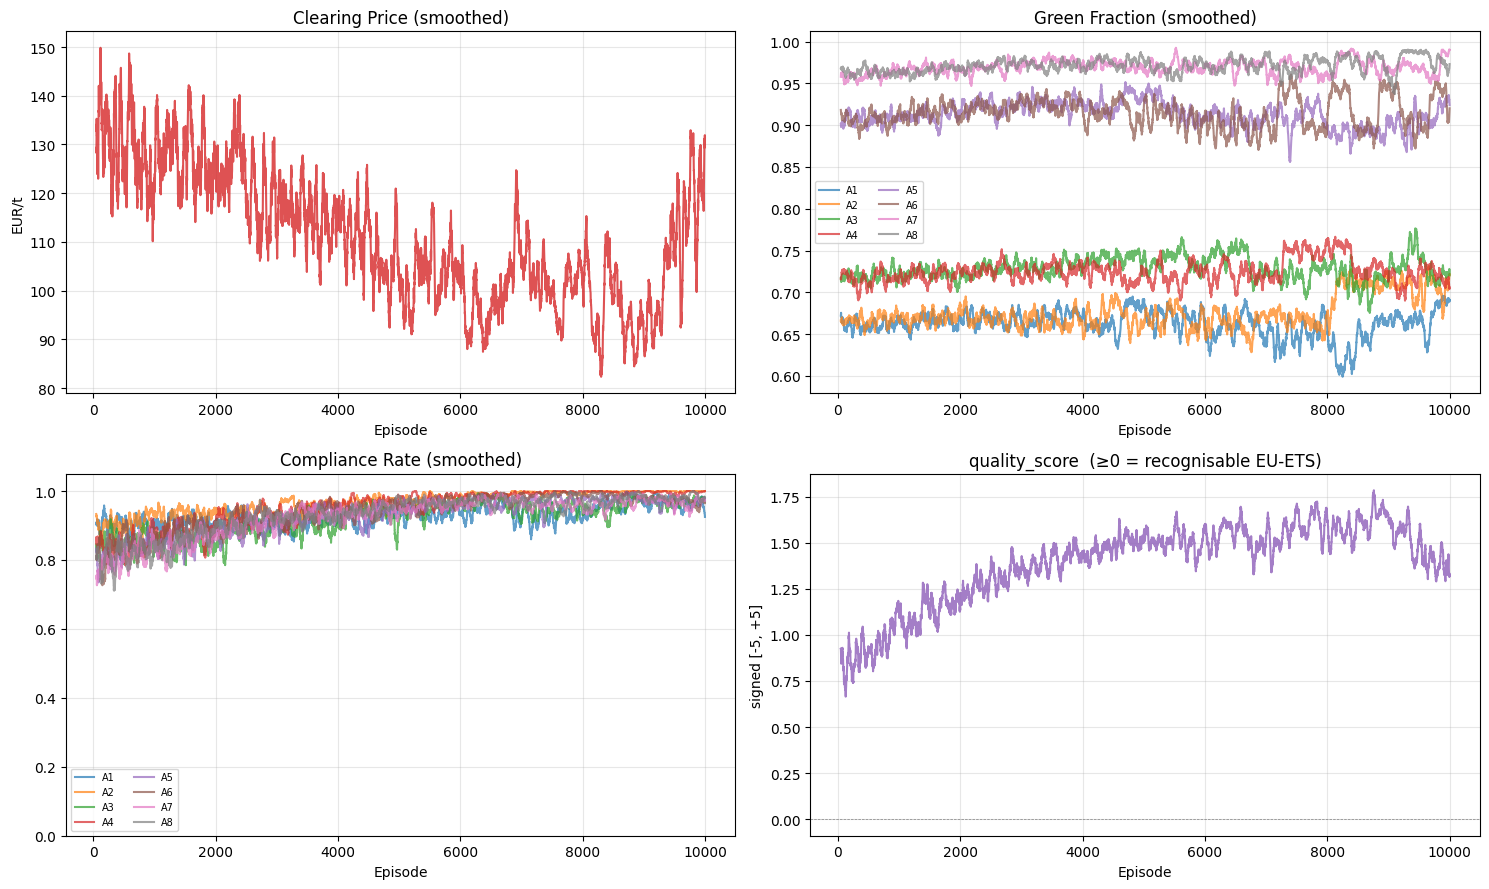

In [13]:
# Price, green fraction, compliance, and quality_score trajectories
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes = axes.ravel()

# Price
prices = ql_df['clearing_price_last'].astype(float)
axes[0].plot(prices.rolling(window).mean(), color='tab:red', alpha=0.8)
axes[0].set_title('Clearing Price (smoothed)')
axes[0].set_xlabel('Episode'); axes[0].set_ylabel('EUR/t')
axes[0].grid(True, alpha=0.3)

# Green fractions per agent
for i in range(n_agents):
    gf = ql_df[f'green_frac_A{i+1}'].astype(float)
    axes[1].plot(gf.rolling(window).mean(), label=f'A{i+1}', alpha=0.7)
axes[1].set_title('Green Fraction (smoothed)')
axes[1].set_xlabel('Episode'); axes[1].legend(fontsize=7, ncol=2)
axes[1].grid(True, alpha=0.3)

# Compliance rate per agent
for i in range(n_agents):
    cr = ql_df[f'compliance_rate_A{i+1}'].astype(float)
    axes[2].plot(cr.rolling(window).mean(), label=f'A{i+1}', alpha=0.7)
axes[2].set_title('Compliance Rate (smoothed)')
axes[2].set_xlabel('Episode'); axes[2].legend(fontsize=7, ncol=2)
axes[2].set_ylim(0, 1.05); axes[2].grid(True, alpha=0.3)

# Quality score (anchor-invariant) — same metric the PPO trainer logs
if 'quality_score' in ql_df.columns:
    qs = pd.to_numeric(ql_df['quality_score'], errors='coerce')
    axes[3].plot(qs.rolling(window).mean(), color='tab:purple', alpha=0.85)
    axes[3].axhline(0, color='grey', lw=0.5, ls='--')
    axes[3].set_title('quality_score  (≥0 = recognisable EU-ETS)')
    axes[3].set_xlabel('Episode'); axes[3].set_ylabel('signed [-5, +5]')
    axes[3].grid(True, alpha=0.3)
else:
    axes[3].set_axis_off()
    axes[3].text(0.5, 0.5, 'quality_score not in CSV\n(re-run training)',
                 ha='center', va='center', transform=axes[3].transAxes)

plt.tight_layout(); plt.show()


## 7. Q-Table Analysis

In [14]:
# Load final Q-tables (already loaded in Cell 15)
if HAS_QTABLES and qtables is not None:
    print(f'Loaded Q-tables for {len(qtables)} agents from: {qtable_path}')
    for key, qt in qtables.items():
        nonzero = np.count_nonzero(qt)
        total = qt.size
        print(f'  {key}: shape={qt.shape}, '
              f'non-zero={nonzero}/{total} ({nonzero/total*100:.1f}%), '
              f'Q range=[{qt.min():.3f}, {qt.max():.3f}]')
else:
    print('No Q-tables available. Skipping Section 7 plots and top-Q analysis.')

Loaded Q-tables for 8 agents from: results/qlearning\qtables_s8191_final.npz
  agent_0: shape=(243, 6, 4), non-zero=1388/5832 (23.8%), Q range=[-5.744, 2.469]
  agent_1: shape=(243, 6, 4), non-zero=1324/5832 (22.7%), Q range=[-2.357, 4.592]
  agent_2: shape=(243, 6, 4), non-zero=1516/5832 (26.0%), Q range=[-5.559, 2.617]
  agent_3: shape=(243, 6, 4), non-zero=1500/5832 (25.7%), Q range=[-2.401, 3.613]
  agent_4: shape=(243, 6, 4), non-zero=999/5832 (17.1%), Q range=[-7.377, 3.793]
  agent_5: shape=(243, 6, 4), non-zero=979/5832 (16.8%), Q range=[-2.604, 4.549]
  agent_6: shape=(243, 6, 4), non-zero=877/5832 (15.0%), Q range=[-8.379, 4.124]
  agent_7: shape=(243, 6, 4), non-zero=869/5832 (14.9%), Q range=[-2.684, 5.336]


c:\Users\danie\Documents\Python_Scripts\Master Thesis\Thesis-Energy-Auction\src\analysis\qlearning_analysis.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.90, 1.0])


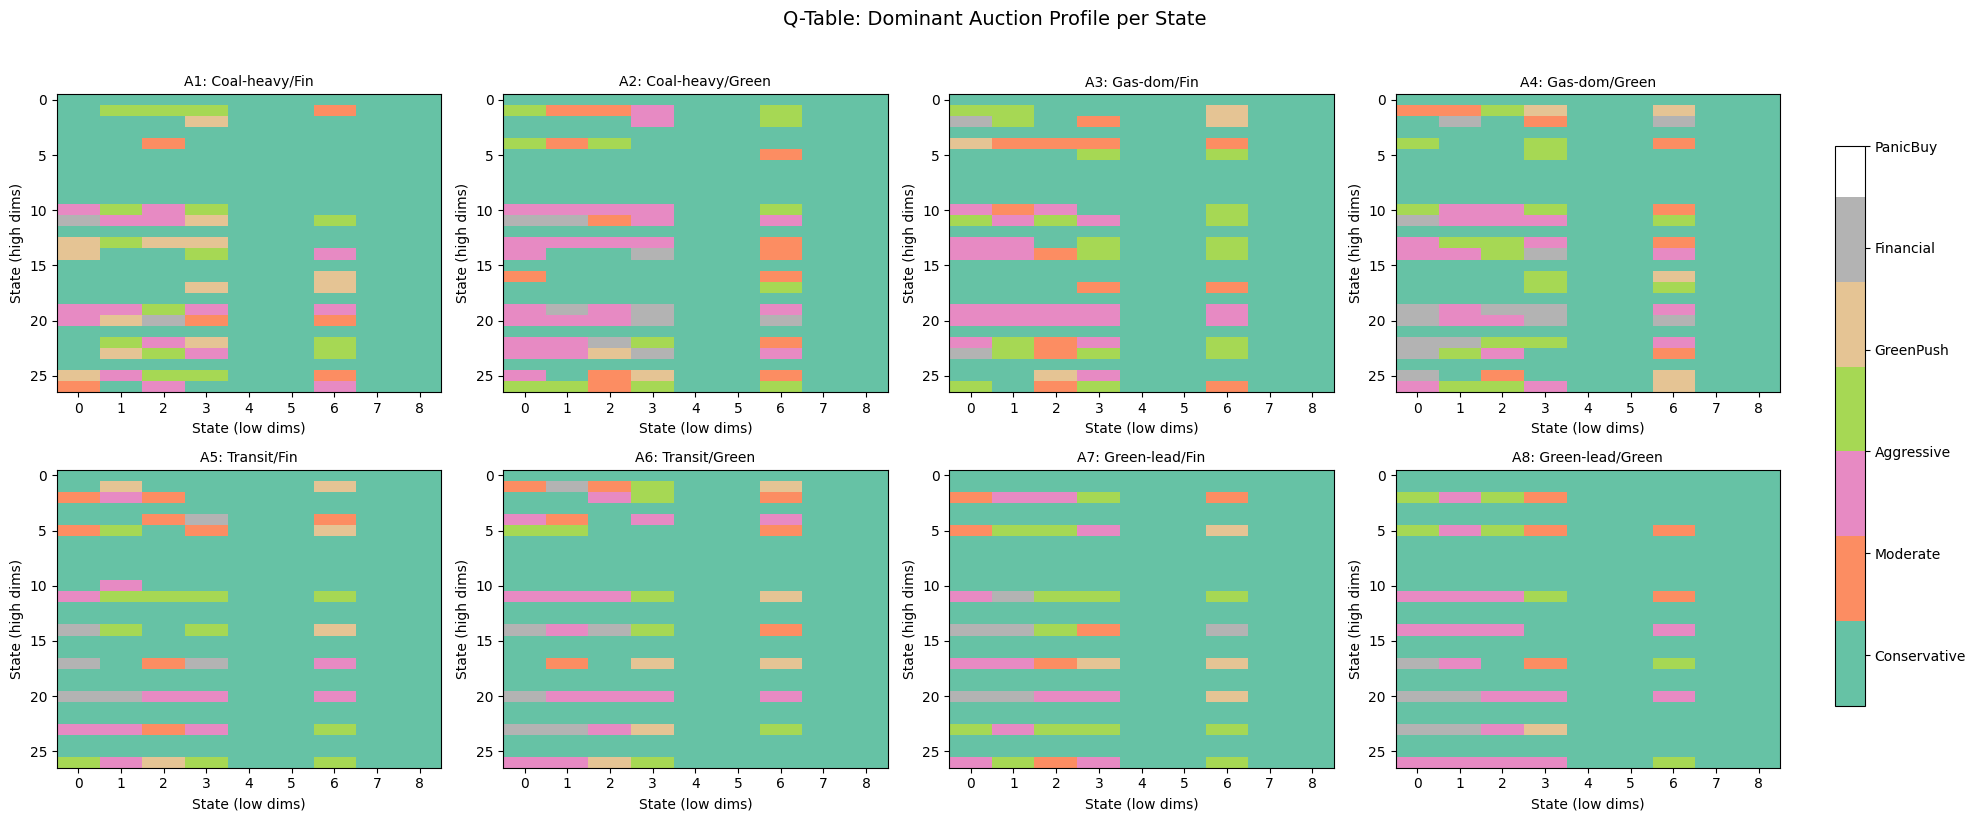

In [15]:
# Q-table heatmaps: dominant auction profile per state
if HAS_QTABLES and qtables is not None:
    plot_qtable_heatmaps(qtables, n_agents)
    plt.show()
else:
    print('Skipped: Q-tables not available.')

c:\Users\danie\Documents\Python_Scripts\Master Thesis\Thesis-Energy-Auction\src\analysis\qlearning_analysis.py:160: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.90, 1.0])


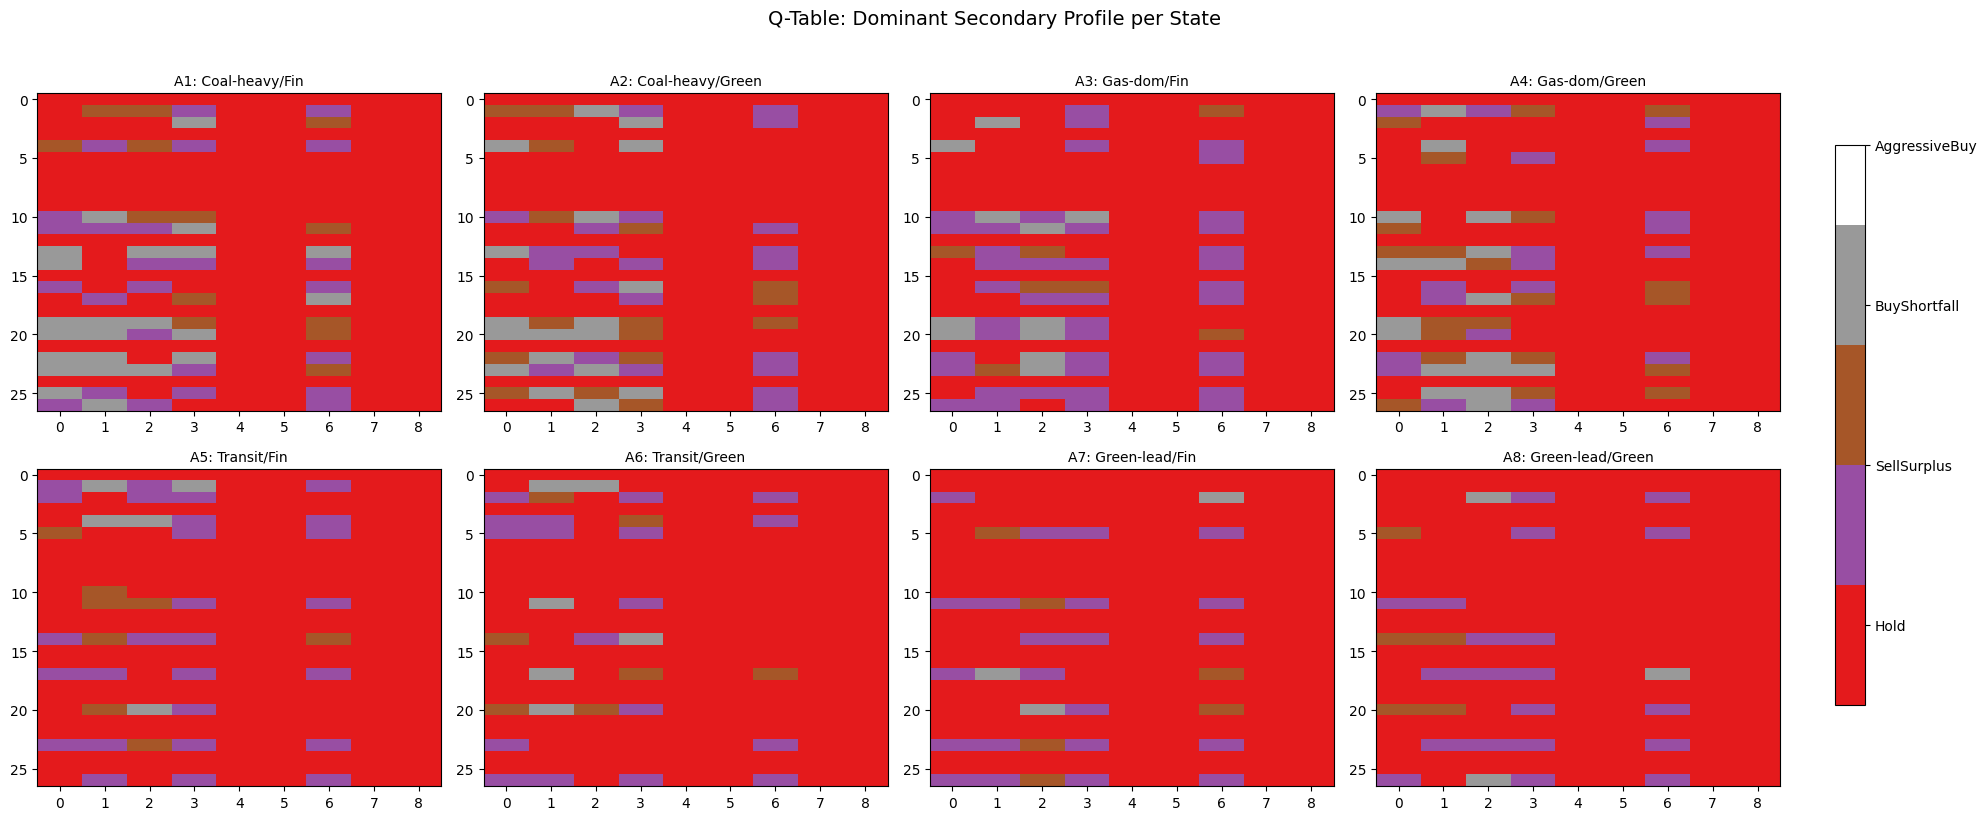

In [16]:
# Q-table heatmaps: dominant secondary profile per state
if HAS_QTABLES and qtables is not None:
    plot_secondary_heatmaps(qtables, n_agents)
    plt.show()
else:
    print('Skipped: Q-tables not available.')

In [17]:
# Top-5 Q-values per agent (works with saved Q-tables, no in-memory agents required)
if HAS_QTABLES and qtables is not None:
    a1_names = ActionProfileMapper.auction_profile_names()
    a2_names = ActionProfileMapper.secondary_profile_names()
    disc = StateDiscretizer()

    for i in range(n_agents):
        key = f'agent_{i}'
        if key not in qtables:
            print(f'\nA{i+1}: Q-table missing ({key})')
            continue

        qt = qtables[key]  # expected shape: [state, auction_profile, secondary_profile]
        k = 5
        flat = qt.reshape(-1)
        top_idx = np.argpartition(flat, -k)[-k:]
        top_idx = top_idx[np.argsort(flat[top_idx])[::-1]]

        print(f'\nA{i+1} ({archetypes[i]}) — Top 5 Q-values:')
        for idx in top_idx:
            s, a1, a2 = np.unravel_index(idx, qt.shape)
            qval = qt[s, a1, a2]
            bins = disc.index_to_bins(int(s))
            state_desc = ', '.join([['early','mid','late'][bins[0]],
                                    ['lowP','medP','highP'][bins[1]],
                                    ['dirty','mixed','green'][bins[2]],
                                    ['deficit','balanced','surplus'][bins[3]],
                                    ['noCF','someCF','heavyCF'][bins[4]]])
            print(f'  Q={qval:+.3f} | state=({state_desc}) | '
                  f'auction={a1_names[a1]} | secondary={a2_names[a2]}')
else:
    print('Skipped: Q-tables not available.')


A1 (Coal/Fin) — Top 5 Q-values:
  Q=+2.469 | state=(early, lowP, mixed, balanced, noCF) | auction=GreenPush | secondary=SellSurplus
  Q=+2.417 | state=(early, lowP, mixed, surplus, noCF) | auction=Moderate | secondary=SellSurplus
  Q=+2.200 | state=(early, lowP, mixed, deficit, noCF) | auction=Conservative | secondary=Hold
  Q=+2.002 | state=(early, lowP, mixed, balanced, noCF) | auction=Conservative | secondary=BuyShortfall
  Q=+1.960 | state=(early, lowP, mixed, balanced, noCF) | auction=Financial | secondary=AggressiveBuy

A2 (Coal/Green) — Top 5 Q-values:
  Q=+4.592 | state=(mid, lowP, mixed, surplus, noCF) | auction=GreenPush | secondary=Hold
  Q=+4.468 | state=(early, lowP, mixed, surplus, noCF) | auction=GreenPush | secondary=SellSurplus
  Q=+4.300 | state=(mid, lowP, mixed, balanced, noCF) | auction=Aggressive | secondary=SellSurplus
  Q=+4.233 | state=(early, lowP, mixed, balanced, noCF) | auction=Aggressive | secondary=SellSurplus
  Q=+4.218 | state=(mid, lowP, mixed, surplu

## 8. Strategy Frequency Analysis

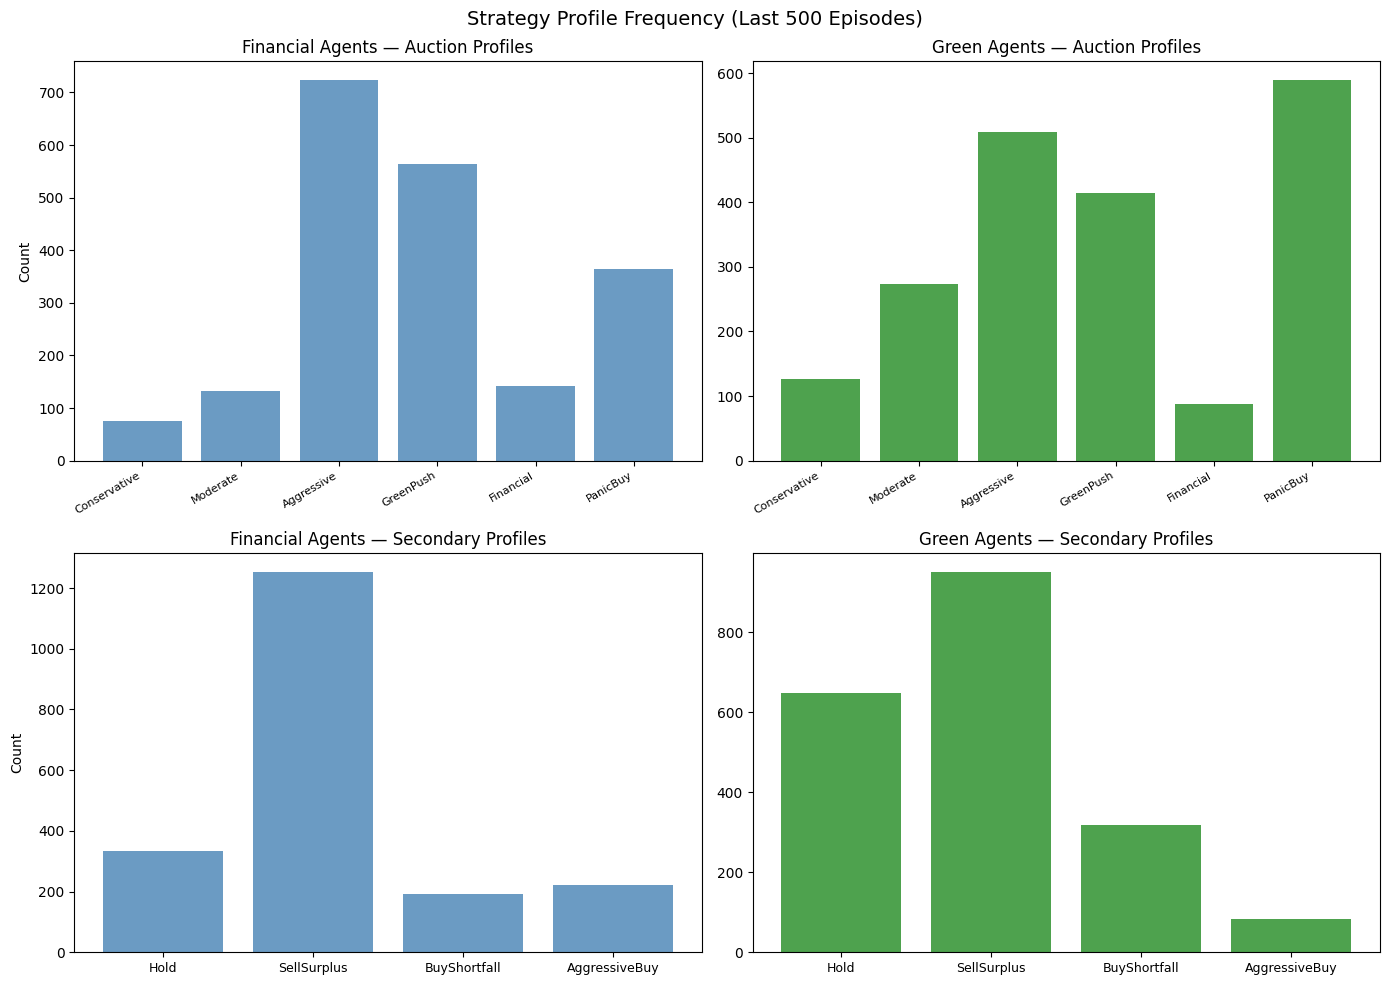

In [18]:
# Strategy frequency in last 500 episodes
plot_strategy_frequency(ql_df, n_agents, last_n=500)
plt.show()

## 9. Greedy Evaluation (100 Episodes)

In [19]:
if EVAL_AGENTS is not None and EVAL_CONFIG is not None:
    eval_results = evaluate_qlearning(
        EVAL_AGENTS, EVAL_CONFIG, seed=SEED,
        n_eval_episodes=100
    )
else:
    eval_results = None
    print('Skipped: evaluation requires trained agents or saved Q-tables.')


Q-Learning Evaluation — 100 greedy episodes (seed 8191)
Market calibration: 8 participants, emissions=20.7 Mt, cap=22.8 Mt
[ETSEnvironment] 8 learning + 0 bot = 8 total agents | cancel_under_subscribed=False
[ETSEnvironment] Initial bank seed example (episode-start allowance holdings, unit: MtCO2 allowances): A1=1.85, A2=1.66, A3=1.78, A4=1.40, A5=1.20, A6=1.04, A7=0.87, A8=0.79
[ETSEnvironment] Context: this is each active agent's starting bank before year-1 actions/compliance; total TNAC seed=10.59 MtCO2.

Evaluation Results (mean ± std over 100 episodes):
  Avg clearing price: 63.8 ± 6.0 €/t
  Avg quality_score:  +1.29 ± 0.20
  A1: reward=+2.55±1.16  green=68.5%  comply=98.4%  short=0.104Mt
  A2: reward=+4.69±1.36  green=71.2%  comply=100.0%  short=0.000Mt
  A3: reward=+2.60±1.37  green=71.2%  comply=95.8%  short=0.562Mt
  A4: reward=+3.76±1.27  green=70.1%  comply=99.9%  short=0.002Mt
  A5: reward=+1.93±1.85  green=90.9%  comply=97.6%  short=0.117Mt
  A6: reward=+5.06±1.66  green=

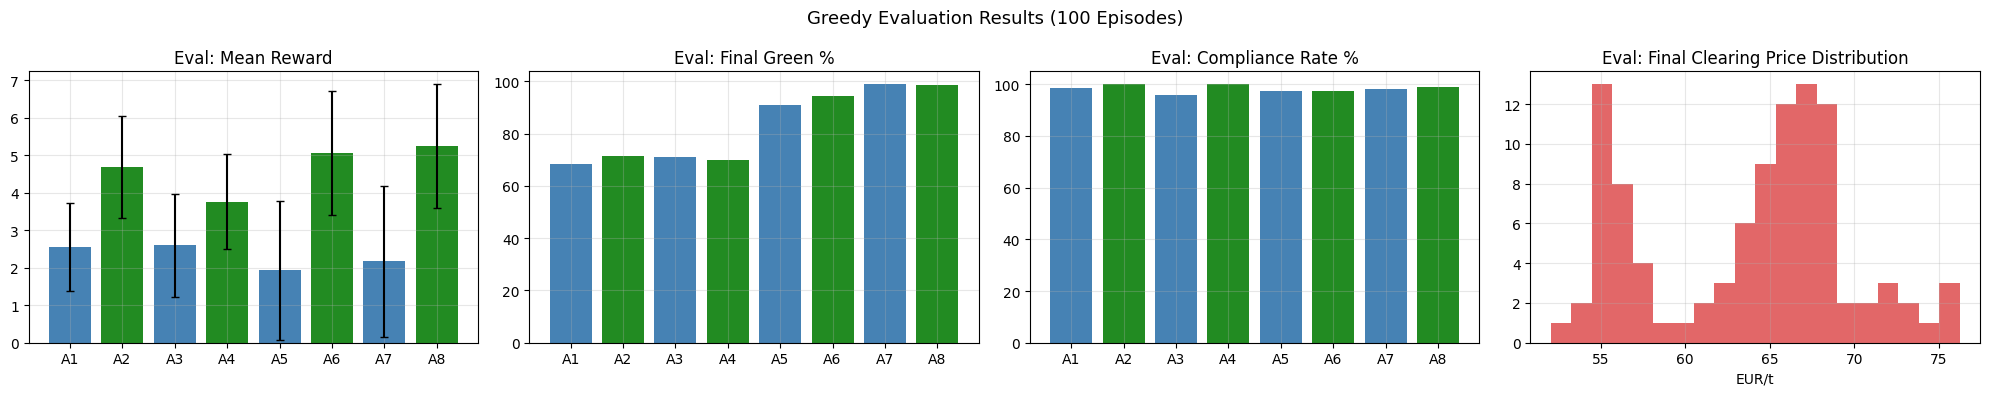

In [20]:
# Evaluation results visualization
if eval_results is not None:
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))

    # Rewards
    mean_rew = eval_results['rewards'].mean(axis=0)
    std_rew = eval_results['rewards'].std(axis=0)
    axes[0].bar(range(n_agents), mean_rew, yerr=std_rew, capsize=3,
                color=['steelblue' if i%2==0 else 'forestgreen' for i in range(n_agents)])
    axes[0].set_title('Eval: Mean Reward')
    axes[0].set_xticks(range(n_agents))
    axes[0].set_xticklabels([f'A{i+1}' for i in range(n_agents)])
    axes[0].grid(True, alpha=0.3)

    # Green fracs
    mean_gf = eval_results['green_fracs'].mean(axis=0)
    axes[1].bar(range(n_agents), mean_gf * 100,
                color=['steelblue' if i%2==0 else 'forestgreen' for i in range(n_agents)])
    axes[1].set_title('Eval: Final Green %')
    axes[1].set_xticks(range(n_agents))
    axes[1].set_xticklabels([f'A{i+1}' for i in range(n_agents)])
    axes[1].grid(True, alpha=0.3)

    # Compliance
    mean_comp = eval_results['compliance'].mean(axis=0)
    axes[2].bar(range(n_agents), mean_comp * 100,
                color=['steelblue' if i%2==0 else 'forestgreen' for i in range(n_agents)])
    axes[2].set_title('Eval: Compliance Rate %')
    axes[2].set_xticks(range(n_agents))
    axes[2].set_xticklabels([f'A{i+1}' for i in range(n_agents)])
    axes[2].set_ylim(0, 105)
    axes[2].grid(True, alpha=0.3)

    # Price distribution
    axes[3].hist(eval_results['prices'], bins=20, color='tab:red', alpha=0.7)
    axes[3].set_title('Eval: Final Clearing Price Distribution')
    axes[3].set_xlabel('EUR/t')
    axes[3].grid(True, alpha=0.3)

    plt.suptitle('Greedy Evaluation Results (100 Episodes)', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print('Skipped: eval_results is not available.')

## 10. Comparison with PPO/HAPPO (if available)

Load PPO training logs and overlay the learning curves.

In [40]:
from src.utils.run_data import log_exists
# Try to load PPO results for comparison
ppo_dir = 'results\sweeps\default'
ppo_log_path = os.path.join(ppo_dir, f'training_log_default_s{SEED}.csv')

if log_exists(ppo_log_path):
    ppo_df = load_run_csv(ppo_log_path)
    print(f'PPO log loaded: {len(ppo_df)} episodes')
    HAS_PPO = True
else:
    print(f'PPO log not found at {ppo_log_path} - comparison plots will show Q-learning only.')
    print('Run PPO training first, then re-run this cell.')
    ppo_df = None
    HAS_PPO = False

PPO log loaded: 120000 episodes


<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
C:\Users\danie\AppData\Local\Temp\ipykernel_26760\908459876.py:3: SyntaxWarning: invalid escape sequence '\s'
  ppo_dir = 'results\sweeps\default'


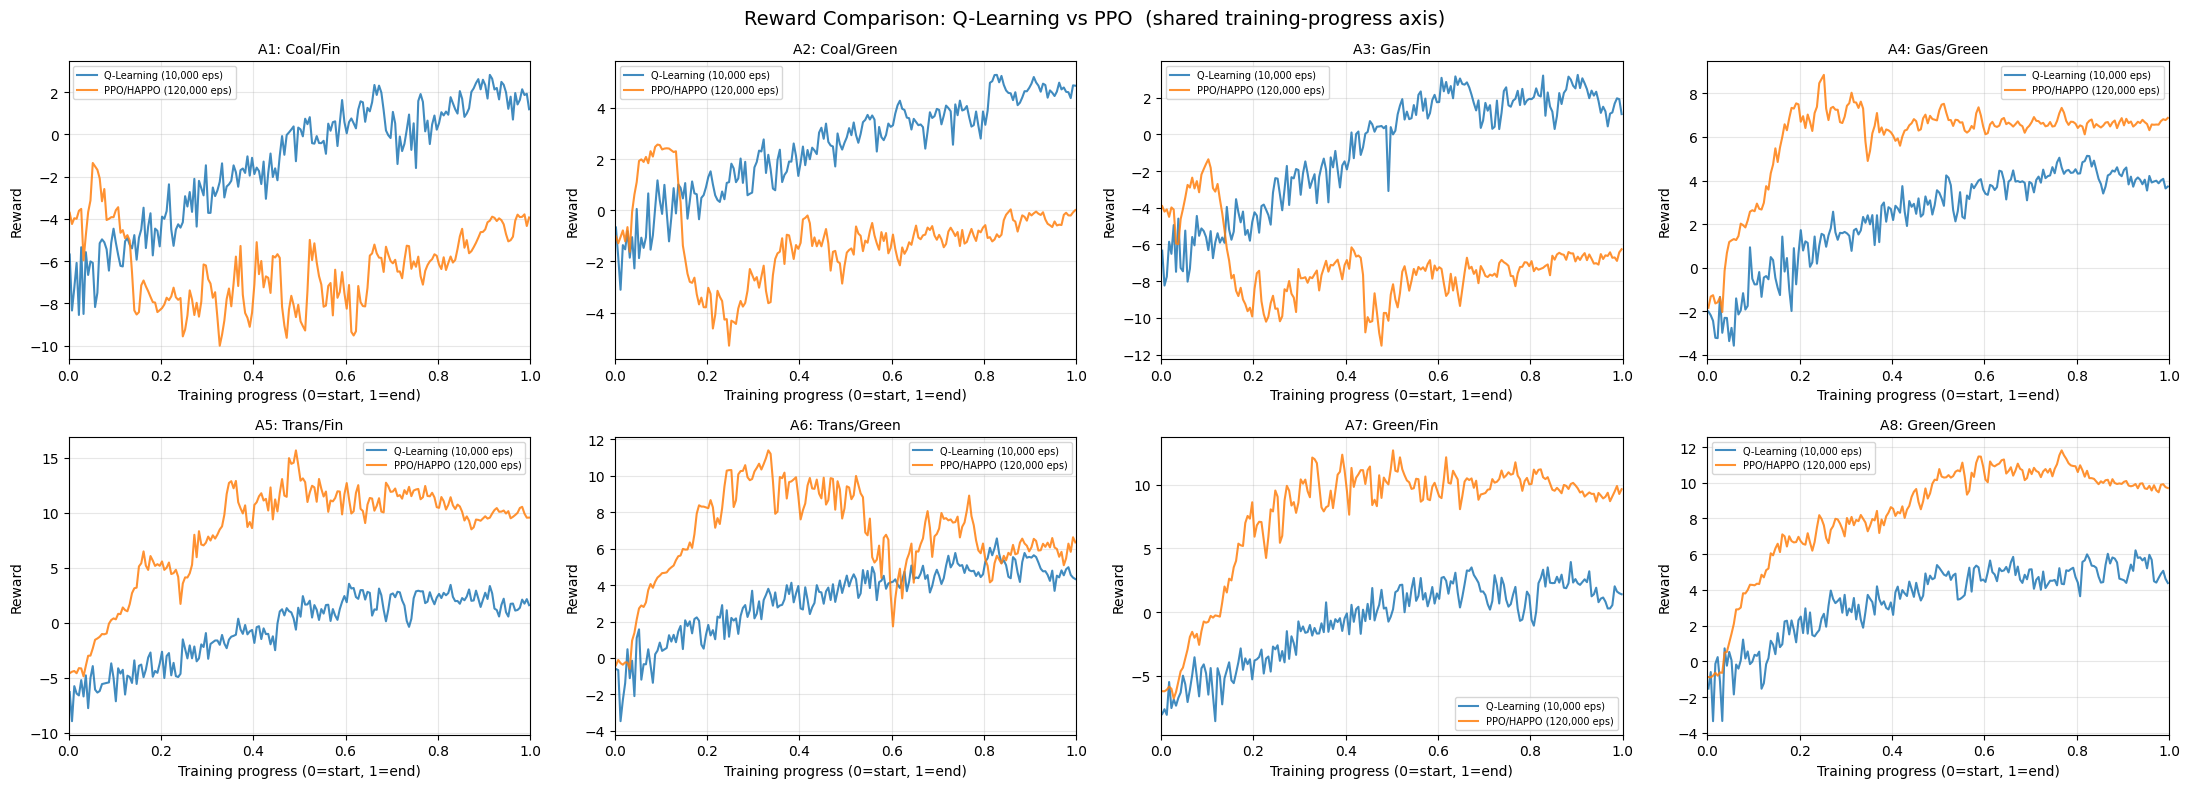

In [57]:
# Reward comparison — shared training-progress axis [0, 1]
# Q-learning trains for ~5k–10k episodes, HAPPO for ~100k. Plotting on raw
# episode index visually crushes the QL curve; rescaling each run to its own
# training progress makes the two algorithms directly comparable.
def _progress_smooth(series, n_bins=200):
    s = pd.to_numeric(series, errors='coerce').dropna().values
    if len(s) < 2:
        return None, None
    n_bins = min(n_bins, len(s))
    progress = np.linspace(0.0, 1.0, len(s))
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    centers = 0.5 * (bins[:-1] + bins[1:])
    idx = np.clip(np.digitize(progress, bins) - 1, 0, n_bins - 1)
    binned = pd.Series(s).groupby(idx).mean().reindex(range(n_bins)).interpolate(limit_direction='both')
    return centers, binned.values

fig, axes = plt.subplots(2, 4, figsize=(22, 8))
fig.suptitle('Reward Comparison: Q-Learning vs PPO  (shared training-progress axis)', fontsize=14)
archetypes_lbl = ['Coal/Fin', 'Coal/Green', 'Gas/Fin', 'Gas/Green',
                  'Trans/Fin', 'Trans/Green', 'Green/Fin', 'Green/Green']

for i in range(n_agents):
    ax = axes[i // 4, i % 4]
    col = f'reward_A{i+1}'
    if col in ql_df.columns:
        x, y = _progress_smooth(ql_df[col])
        if x is not None:
            ax.plot(x, y, label=f'Q-Learning ({len(ql_df):,} eps)', color='tab:blue', alpha=0.85)
    if HAS_PPO and col in ppo_df.columns:
        x, y = _progress_smooth(ppo_df[col])
        if x is not None:
            ax.plot(x, y, label=f'PPO/HAPPO ({len(ppo_df):,} eps)', color='tab:orange', alpha=0.85)
    ax.set_title(f'A{i+1}: {archetypes_lbl[i]}', fontsize=10)
    ax.set_xlabel('Training progress (0=start, 1=end)')
    ax.set_ylabel('Reward')
    ax.set_xlim(0.0, 1.0)
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


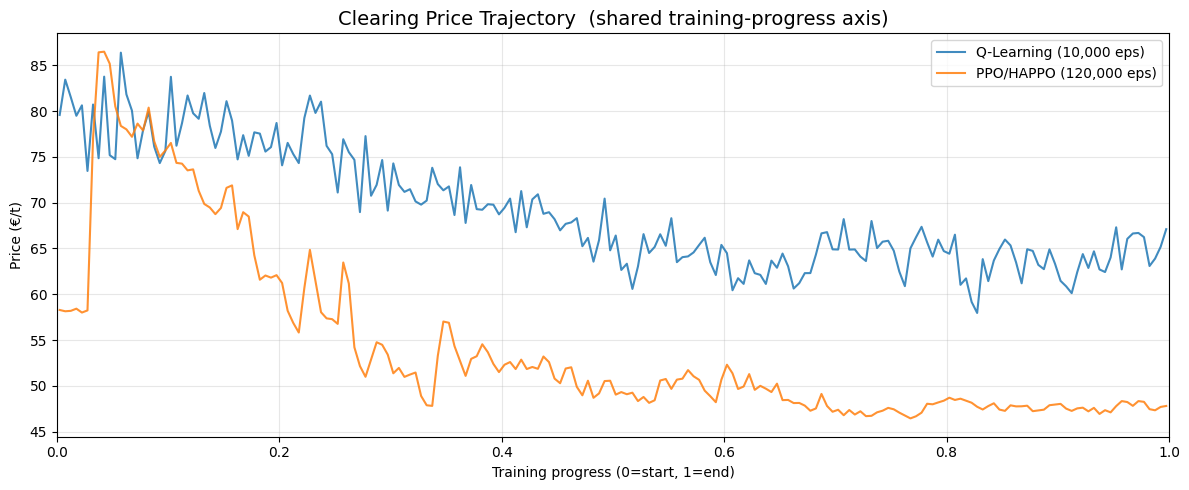

In [58]:
# Price comparison — shared training-progress axis
fig, ax = plt.subplots(figsize=(12, 5))

px_col_ql  = 'ep_mean_clearing_price' if 'ep_mean_clearing_price' in ql_df.columns else 'clearing_price_last'
if px_col_ql in ql_df.columns:
    x, y = _progress_smooth(ql_df[px_col_ql])
    if x is not None:
        ax.plot(x, y, label=f'Q-Learning ({len(ql_df):,} eps)', color='tab:blue', alpha=0.85)

if HAS_PPO:
    px_col_ppo = 'ep_mean_clearing_price' if 'ep_mean_clearing_price' in ppo_df.columns else 'clearing_price_last'
    if px_col_ppo in ppo_df.columns:
        x, y = _progress_smooth(ppo_df[px_col_ppo])
        if x is not None:
            ax.plot(x, y, label=f'PPO/HAPPO ({len(ppo_df):,} eps)', color='tab:orange', alpha=0.85)

ax.set_title('Clearing Price Trajectory  (shared training-progress axis)', fontsize=14)
ax.set_xlabel('Training progress (0=start, 1=end)')
ax.set_ylabel('Price (€/t)')
ax.set_xlim(0.0, 1.0)
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


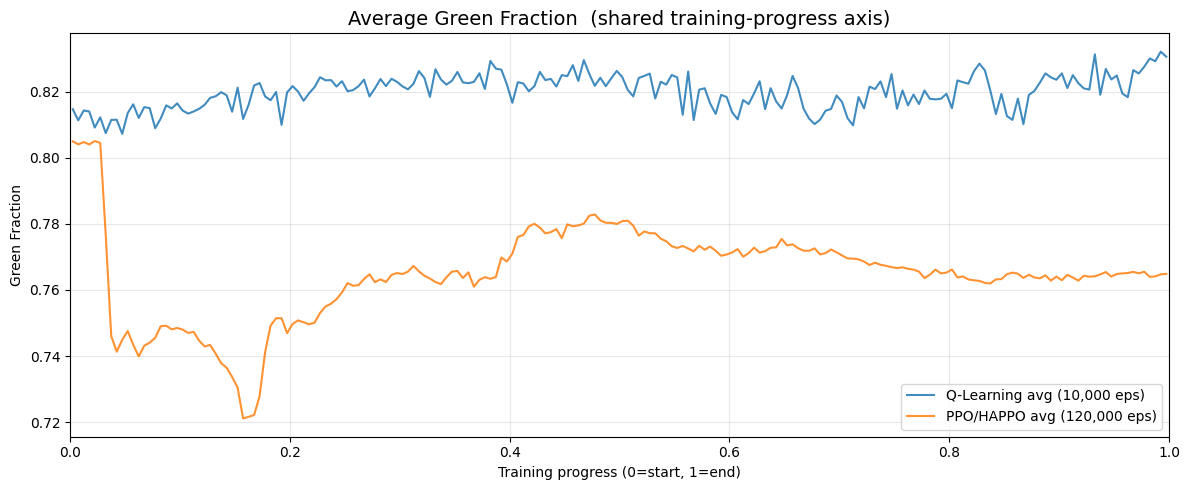

In [60]:
# Green fraction comparison — shared training-progress axis
fig, ax = plt.subplots(figsize=(12, 5))

gf_cols = [f'green_frac_A{i+1}' for i in range(n_agents)]

ql_avail = [c for c in gf_cols if c in ql_df.columns]
if ql_avail:
    ql_avg = ql_df[ql_avail].apply(pd.to_numeric, errors='coerce').mean(axis=1)
    x, y = _progress_smooth(ql_avg)
    if x is not None:
        ax.plot(x, y, label=f'Q-Learning avg ({len(ql_df):,} eps)', color='tab:blue', alpha=0.85)

if HAS_PPO:
    ppo_avail = [c for c in gf_cols if c in ppo_df.columns]
    if ppo_avail:
        ppo_avg = ppo_df[ppo_avail].apply(pd.to_numeric, errors='coerce').mean(axis=1)
        x, y = _progress_smooth(ppo_avg)
        if x is not None:
            ax.plot(x, y, label=f'PPO/HAPPO avg ({len(ppo_df):,} eps)', color='tab:orange', alpha=0.85)

ax.set_title('Average Green Fraction  (shared training-progress axis)', fontsize=14)
ax.set_xlabel('Training progress (0=start, 1=end)')
ax.set_ylabel('Green Fraction')
ax.set_xlim(0.0, 1.0)
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


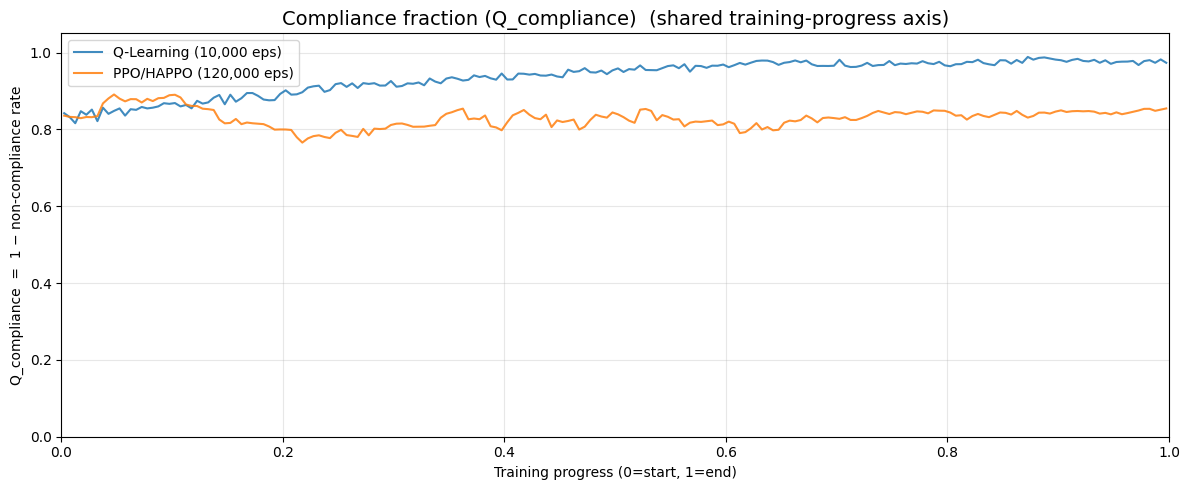

In [62]:
# Compliance comparison — shared training-progress axis
# Both trainers log `Q_compliance` (= 1 − non-compliance rate, the same
# fraction that feeds quality_score). It's the only compliance metric that
# is structurally identical in both training_logs:
#   * PPO's training_log has shortfall_A{i+1} as an *episode-sum* (Mt),
#     so a naive `shortfall < ε` underestimates compliance dramatically.
#   * Q-learning's training_log has compliance_rate_A{i+1} per agent, but
#     PPO's does not.
# Q_compliance is a fraction in [0,1] computed identically on both sides.
fig, ax = plt.subplots(figsize=(12, 5))

if 'Q_compliance' in ql_df.columns:
    x, y = _progress_smooth(ql_df['Q_compliance'])
    if x is not None:
        ax.plot(x, y, label=f'Q-Learning ({len(ql_df):,} eps)', color='tab:blue', alpha=0.85)
elif any(f'compliance_rate_A{i+1}' in ql_df.columns for i in range(n_agents)):
    # Older QL logs without Q_compliance: fall back to per-agent mean.
    cols = [f'compliance_rate_A{i+1}' for i in range(n_agents) if f'compliance_rate_A{i+1}' in ql_df.columns]
    ql_avg = ql_df[cols].apply(pd.to_numeric, errors='coerce').mean(axis=1)
    x, y = _progress_smooth(ql_avg)
    if x is not None:
        ax.plot(x, y, label=f'Q-Learning avg [legacy] ({len(ql_df):,} eps)', color='tab:blue', alpha=0.85)

if HAS_PPO and 'Q_compliance' in ppo_df.columns:
    x, y = _progress_smooth(ppo_df['Q_compliance'])
    if x is not None:
        ax.plot(x, y, label=f'PPO/HAPPO ({len(ppo_df):,} eps)', color='tab:orange', alpha=0.85)
elif HAS_PPO:
    print('PPO log lacks `Q_compliance`. Re-run training to populate the quality-metric '
          'columns; episode-summed shortfall is not a reliable compliance proxy.')

ax.set_title('Compliance fraction (Q_compliance)  (shared training-progress axis)', fontsize=14)
ax.set_xlabel('Training progress (0=start, 1=end)')
ax.set_ylabel('Q_compliance  =  1 − non-compliance rate')
ax.set_xlim(0.0, 1.0); ax.set_ylim(0, 1.05)
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


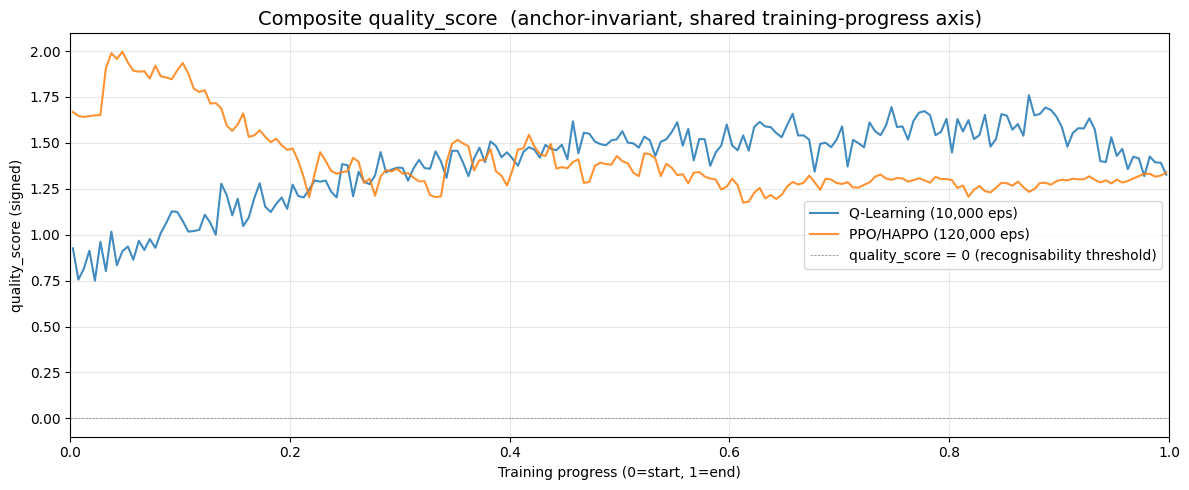

In [59]:
# Quality score comparison — shared training-progress axis
# `quality_score` is the anchor-invariant composite metric the PPO trainer
# also logs, so it's directly comparable across algorithms.
fig, ax = plt.subplots(figsize=(12, 5))

if 'quality_score' in ql_df.columns:
    x, y = _progress_smooth(ql_df['quality_score'])
    if x is not None:
        ax.plot(x, y, label=f'Q-Learning ({len(ql_df):,} eps)', color='tab:blue', alpha=0.85)

if HAS_PPO and 'quality_score' in ppo_df.columns:
    x, y = _progress_smooth(ppo_df['quality_score'])
    if x is not None:
        ax.plot(x, y, label=f'PPO/HAPPO ({len(ppo_df):,} eps)', color='tab:orange', alpha=0.85)

ax.axhline(0, color='grey', lw=0.5, ls='--', label='quality_score = 0 (recognisability threshold)')
ax.set_title('Composite quality_score  (anchor-invariant, shared training-progress axis)', fontsize=14)
ax.set_xlabel('Training progress (0=start, 1=end)')
ax.set_ylabel('quality_score (signed)')
ax.set_xlim(0.0, 1.0)
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 11. Single-seed summary statistics

In [45]:
# Final summary table
last_500 = ql_df.tail(500)

summary_data = []
for i in range(n_agents):
    row = {
        'Agent': f'A{i+1}',
        'Archetype': archetypes[i],
        'Avg Reward': last_500[f'reward_A{i+1}'].astype(float).mean(),
        'Final Green %': last_500[f'green_frac_A{i+1}'].astype(float).mean() * 100,
        'Compliance %': last_500[f'compliance_rate_A{i+1}'].astype(float).mean() * 100,
        'Avg Shortfall': last_500[f'shortfall_A{i+1}'].astype(float).mean(),
    }
    summary_data.append(row)

summary_df = pd.DataFrame(summary_data)
print('Q-Learning Performance (last 500 training episodes):')
print(summary_df.to_string(index=False, float_format='%.2f'))

if HAS_PPO:
    print('\n--- For comparison, PPO (last 500 episodes): ---')
    ppo_last = ppo_df.tail(500)
    for i in range(n_agents):
        col_r = f'reward_A{i+1}'
        col_g = f'green_frac_A{i+1}'
        if col_r in ppo_last.columns:
            ppo_rew = ppo_last[col_r].astype(float).mean()
            ppo_gf = ppo_last[col_g].astype(float).mean() * 100 if col_g in ppo_last.columns else 0
            print(f'  A{i+1}: reward={ppo_rew:.2f}, green={ppo_gf:.1f}%')

Q-Learning Performance (last 500 training episodes):
Agent   Archetype  Avg Reward  Final Green %  Compliance %  Avg Shortfall
   A1    Coal/Fin        1.59          67.34         96.00           0.50
   A2  Coal/Green        4.70          70.65         99.95           0.00
   A3     Gas/Fin        1.33          72.22         96.77           0.37
   A4   Gas/Green        3.89          72.18         99.58           0.02
   A5   Trans/Fin        1.53          91.49         96.72           0.14
   A6 Trans/Green        4.51          92.50         96.89           0.14
   A7   Green/Fin        1.07          96.97         96.54           0.11
   A8 Green/Green        4.94          97.76         98.40           0.03

--- For comparison, PPO (last 500 episodes): ---
  A1: reward=-3.91, green=59.2%
  A2: reward=-0.01, green=69.8%
  A3: reward=-6.25, green=57.7%
  A4: reward=6.84, green=75.0%
  A5: reward=9.51, green=72.9%
  A6: reward=6.30, green=79.1%
  A7: reward=9.62, green=98.9%
  A8: rewar

## 12. Sub-RQ 1 — Q-learning vs the default-config PPO sweep

**Sub-RQ 1 (simulation credibility).** *What environment and algorithm design choices are required to build a stable and behaviourally credible simulation of a carbon market?* The two operational claims we want to defend are:

* **RQ 1.a — convergence.** Agents converge to stable policies within a recognisable horizon.
* **RQ 1.b — reproducibility.** Findings replicate across seeds; cross-seed noise stays bounded.

Q-learning's role here is **as a floor**, not a contender. Tabular Q-learning runs in the *same* environment as PPO — same auction, same MSR, same warm-start — but compresses observations to 243 discrete states and the action space to 24 hand-coded profiles. If an environment is too simple, both algorithms succeed and the credibility of the PPO result is unclear. If the environment is too pathological, neither succeeds. The **gap** between Q-learning and PPO on the cross-seed metrics below is what tells us the simulation is non-trivial *and* solvable — i.e. credible.

Concretely, this section:
1. Loads the default-config PPO sweep (`results/sweeps/default_seeds/default/training_log_s*.csv`).
2. Loads all available Q-learning seeds (`results/qlearning/ql_training_log_s*.csv`).
3. Builds **cross-seed fan charts** for the four headline metrics: clearing price, compliance rate, mean    green fraction, and `quality_score`.
4. Reports a small **convergence-plateau** check (rolling-mean tolerance band, à la C1 in the data-science    plan).
5. Tabulates **converged-window** mean ± std for both algorithms side by side.


In [74]:
# 12.1  Locate sweep + Q-learning logs
import glob, re

# Default-config PPO sweep — see configs/sweeps/default_seeds.yaml
SWEEP_DIR_CANDIDATES = [
    'results/sweeps/default',                   # user's actual on-disk layout (preset)
    'results/sweeps/default_seeds/default',     # canonical sweep output
    'results/sweeps/default_seeds',             # fallback if variants are flattened
    'results',                                  # fallback: any training_log_s*.csv under results/
]

def _seed_from(path, prefix):
    # glob_run_logs may return .csv or .parquet siblings, so accept both.
    m = re.search(rf'{re.escape(prefix)}_s(\d+)\.(?:csv|parquet)$', path.replace('\\', '/'))
    return int(m.group(1)) if m else None

ppo_logs = {}
for d in SWEEP_DIR_CANDIDATES:
    if not os.path.isdir(d):
        continue
    paths = sorted(glob_run_logs(os.path.join(d, 'training_log_*s*.csv')))
    for p in paths:
        # Match both `training_log_s{seed}` and `training_log_<tag>_s{seed}`,
        # for either .csv or .parquet siblings produced by end-of-run compression.
        m = re.search(r'training_log(?:_[^/]*?)?_s(\d+)\.(?:csv|parquet)$', p.replace('\\', '/'))
        if m is None:
            continue
        s = int(m.group(1))
        if s not in ppo_logs:
            ppo_logs[s] = p
    if ppo_logs:
        break

ql_paths = sorted(glob_run_logs('results/qlearning/ql_training_log_s*.csv'))
ql_logs = {_seed_from(p, 'ql_training_log'): p for p in ql_paths
           if _seed_from(p, 'ql_training_log') is not None}

# Restrict to the intersection of seeds — apples-to-apples comparison.
# Only keep seeds where BOTH a Q-learning and a PPO run exist.
ql_seeds_all  = sorted(ql_logs)
ppo_seeds_all = sorted(ppo_logs)
shared_seeds  = sorted(set(ql_logs) & set(ppo_logs))
ql_logs  = {s: ql_logs[s]  for s in shared_seeds}
ppo_logs = {s: ppo_logs[s] for s in shared_seeds}

print(f'Q-learning seeds available ({len(ql_seeds_all):2d}): {ql_seeds_all}')
print(f'PPO sweep  seeds available ({len(ppo_seeds_all):2d}): {ppo_seeds_all}')
print(f'Matched seeds (used)       ({len(shared_seeds):2d}): {shared_seeds}')

HAS_SWEEP = len(shared_seeds) >= 1
if not HAS_SWEEP:
    print('\nNo overlapping seeds between Q-learning and PPO — skipping cross-seed comparison.')


Q-learning seeds available ( 5): [42, 1729, 5041, 6561, 8191]
PPO sweep  seeds available ( 8): [219, 581, 738, 904, 1729, 5041, 6561, 8191]
Matched seeds (used)       ( 4): [1729, 5041, 6561, 8191]


In [85]:
# 12.2  Cross-seed loader — pulls the four credibility metrics into a tidy long frame
if HAS_SWEEP:
    PPO_METRICS = {
        'clearing_price':  ['ep_mean_clearing_price', 'clearing_price_last'],
        'compliance_rate': None,   # mean over agent compliance_rate_A* / shortfall_A*
        'green_frac':      None,   # mean over agent green_frac_A*
        'quality_score':   ['quality_score'],
    }

    def _agent_mean(df, prefix, n_total):
        cols = [f'{prefix}_A{i+1}' for i in range(n_total) if f'{prefix}_A{i+1}' in df.columns]
        if not cols:
            return None
        return df[cols].apply(pd.to_numeric, errors='coerce').mean(axis=1)

    def _ppo_compliance(df, n_total):
        # Prefer the anchor-invariant `Q_compliance` (= 1 − non-compliance rate)
        # which BOTH trainers log identically. PPO's training_log records
        # shortfall_A* as an episode-sum (Mt), so a naive `shortfall < ε`
        # underestimates compliance dramatically.
        if 'Q_compliance' in df.columns:
            return pd.to_numeric(df['Q_compliance'], errors='coerce')
        cols = [f'compliance_rate_A{i+1}' for i in range(n_total) if f'compliance_rate_A{i+1}' in df.columns]
        if cols:
            return df[cols].apply(pd.to_numeric, errors='coerce').mean(axis=1)
        # Last-resort fallback: derive from shortfall (legacy logs only).
        sf = [f'shortfall_A{i+1}' for i in range(n_total) if f'shortfall_A{i+1}' in df.columns]
        if not sf:
            return None
        return (df[sf].apply(pd.to_numeric, errors='coerce') < 1e-6).mean(axis=1)

    def _series(df, metric, n_total):
        if metric == 'compliance_rate':
            return _ppo_compliance(df, n_total)
        if metric == 'green_frac':
            return _agent_mean(df, 'green_frac', n_total)
        for col in (PPO_METRICS[metric] or []):
            if col in df.columns:
                return pd.to_numeric(df[col], errors='coerce')
        return None

    n_total_cfg = config['companies']['n_agents'] + config['companies'].get('n_bot_agents', 0)

    def _stack(logs):
        """Return dict[metric] -> DataFrame with columns = seeds and rows = episode index."""
        out = {m: {} for m in PPO_METRICS}
        for seed, path in sorted(logs.items()):
            df = load_run_csv(path)
            for m in PPO_METRICS:
                s = _series(df, m, n_total_cfg)
                if s is not None:
                    out[m][seed] = s.reset_index(drop=True)
        return {m: pd.DataFrame(d) for m, d in out.items() if d}

    ppo_stacks = _stack(ppo_logs)
    ql_stacks  = _stack(ql_logs)
    print({m: f'{ppo_stacks[m].shape} ppo / '
              f'{ql_stacks.get(m, pd.DataFrame()).shape} ql' for m in ppo_stacks})


{'clearing_price': '(120000, 4) ppo / (10000, 4) ql', 'compliance_rate': '(120000, 4) ppo / (10000, 4) ql', 'green_frac': '(120000, 4) ppo / (10000, 4) ql', 'quality_score': '(120000, 4) ppo / (10000, 4) ql'}


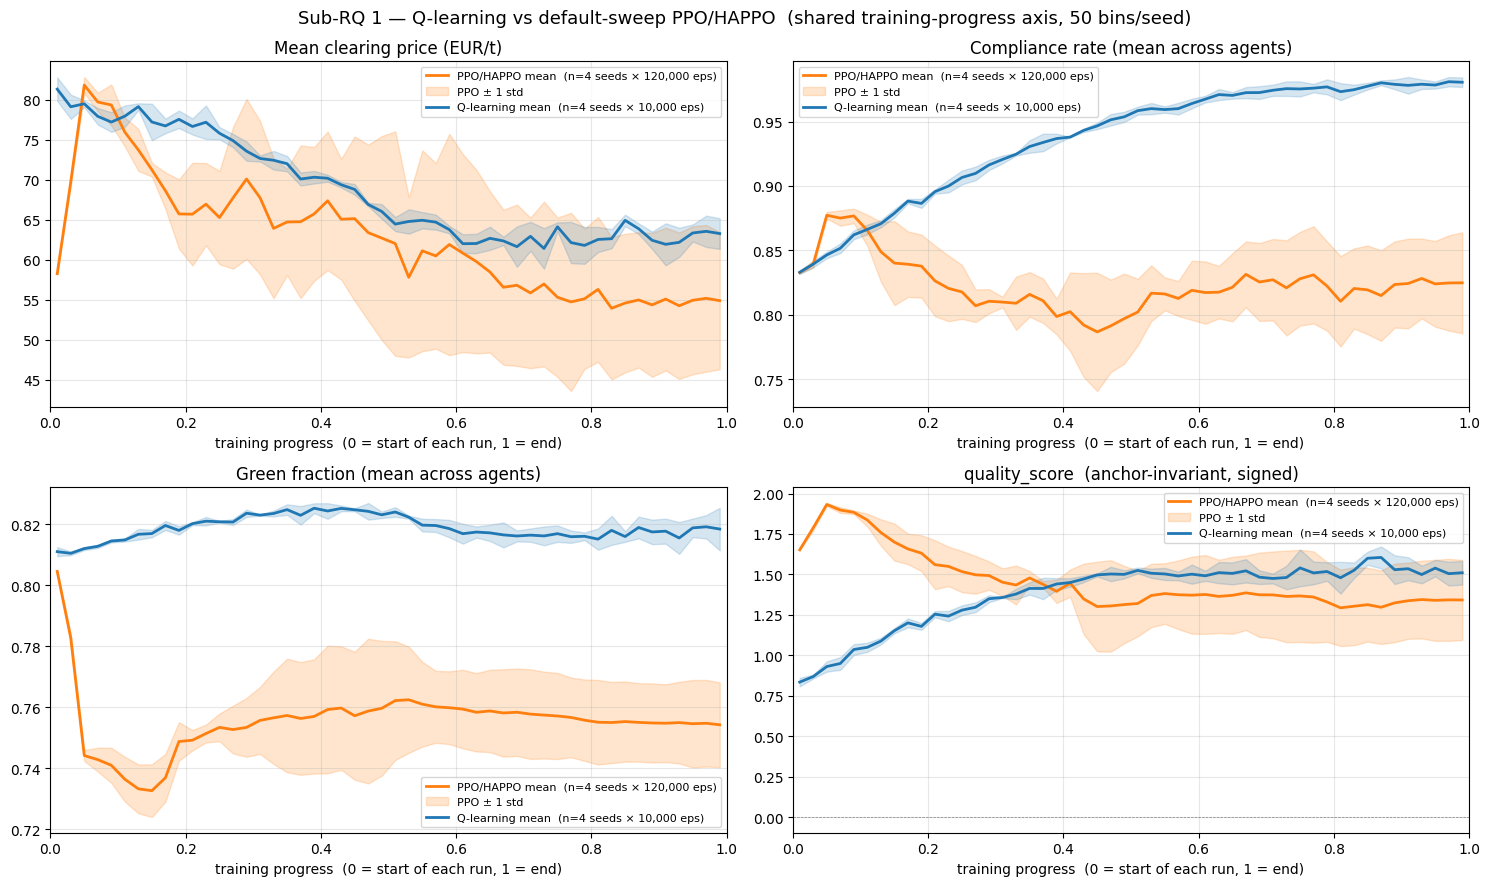

In [86]:
# 12.3  Fan charts on a SHARED training-progress axis [0, 1].
# Q-learning typically trains for 5k–10k episodes while HAPPO runs 100k;
# plotting both on episode-index would dwarf the Q-learning curve.
# Instead, each seed is rebinned onto 50 evenly-spaced training-progress
# bins, then averaged across seeds. The result is apples-to-apples even
# when the absolute episode budgets differ by 10–100×.
if HAS_SWEEP:
    N_BINS = 50

    def _band_progress(stack_df, n_bins=N_BINS):
        """Return (centers, mean_across_seeds, std_across_seeds) on [0,1]."""
        if stack_df is None or stack_df.empty:
            return None
        bins = np.linspace(0.0, 1.0, n_bins + 1)
        centers = 0.5 * (bins[:-1] + bins[1:])
        per_seed = []
        for col in stack_df.columns:
            s = pd.to_numeric(stack_df[col], errors='coerce').dropna().values
            if len(s) < 2:
                continue
            progress = np.linspace(0.0, 1.0, len(s))
            idx = np.clip(np.digitize(progress, bins) - 1, 0, n_bins - 1)
            binned = pd.Series(s).groupby(idx).mean()
            binned = binned.reindex(range(n_bins)).interpolate(limit_direction='both')
            per_seed.append(binned.values)
        if not per_seed:
            return None
        M = np.vstack(per_seed)
        return centers, np.nanmean(M, axis=0), np.nanstd(M, axis=0)

    fig, axes = plt.subplots(2, 2, figsize=(15, 9))
    axes = axes.ravel()
    metric_titles = {
        'clearing_price':  'Mean clearing price (EUR/t)',
        'compliance_rate': 'Compliance rate (mean across agents)',
        'green_frac':      'Green fraction (mean across agents)',
        'quality_score':   'quality_score  (anchor-invariant, signed)',
    }
    n_ppo_eps = int(np.mean([d.shape[0] for d in ppo_stacks.values()])) if ppo_stacks else 0
    n_ql_eps  = int(np.mean([d.shape[0] for d in ql_stacks.values()])) if ql_stacks else 0
    for ax, metric in zip(axes, metric_titles):
        ppo_band = _band_progress(ppo_stacks.get(metric))
        ql_band  = _band_progress(ql_stacks.get(metric))
        if ppo_band is not None:
            x, m, s = ppo_band
            ax.plot(x, m, color='tab:orange', lw=2,
                    label=f'PPO/HAPPO mean  (n={ppo_stacks[metric].shape[1]} seeds × {n_ppo_eps:,} eps)')
            ax.fill_between(x, m - s, m + s, color='tab:orange', alpha=0.2, label='PPO ± 1 std')
        if ql_band is not None:
            x, m, s = ql_band
            ax.plot(x, m, color='tab:blue', lw=2,
                    label=f'Q-learning mean  (n={ql_stacks[metric].shape[1]} seeds × {n_ql_eps:,} eps)')
            ax.fill_between(x, m - s, m + s, color='tab:blue', alpha=0.18)
        if metric == 'quality_score':
            ax.axhline(0, color='grey', lw=0.5, ls='--')
        ax.set_title(metric_titles[metric])
        ax.set_xlabel('training progress  (0 = start of each run, 1 = end)')
        ax.set_xlim(0.0, 1.0)
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    plt.suptitle('Sub-RQ 1 — Q-learning vs default-sweep PPO/HAPPO  '
                 '(shared training-progress axis, 50 bins/seed)', fontsize=13)
    plt.tight_layout(); plt.show()


In [77]:
# 12.4  Plateau detection — training-budget-aware: each algorithm is
#       evaluated on its OWN episode-index, so a 5k-episode Q-learning
#       run and a 100k-episode HAPPO run both report the first plateau
#       relative to their own training budget. The plateau row also
#       prints n_episodes per source so it's clear what "same episode"
#       means.
# 12.4  Plateau detection — first episode where the rolling mean stays inside a
#       tolerance band for K consecutive windows. Mirrors the C1 method in
#       planning/data_science_analysis_plan.md (RQ 1.a).
if HAS_SWEEP:
    def first_plateau(series: pd.Series, win: int | None = None, tol: float = 0.05,
                      k_windows: int = 4) -> int | None:
        """Return episode index of the first window whose rolling mean stays
        within ±tol·|level| of its median for k_windows consecutive windows;
        None if no plateau is reached."""
        # Auto-size the smoothing window to ~2% of the series length
        # so QL's 5k-episode runs aren't starved by a fixed 50-window.
        if win is None:
            win = max(20, len(series) // 50)
        s = pd.to_numeric(series, errors='coerce').rolling(win).mean().dropna()
        if len(s) < k_windows * win:
            return None
        for start in range(len(s) - k_windows * win):
            window_vals = s.iloc[start:start + k_windows * win]
            level = window_vals.median()
            band = max(abs(level), 1.0) * tol
            if (window_vals.max() - window_vals.min()) <= 2 * band:
                return int(s.index[start])
        return None

    rows = []
    for label, stack in [('Q-learning', ql_stacks), ('PPO sweep', ppo_stacks)]:
        for metric in ['clearing_price', 'quality_score', 'compliance_rate']:
            df = stack.get(metric)
            if df is None or df.empty:
                continue
            mean_series = df.mean(axis=1)
            ep = first_plateau(mean_series)
            rows.append({
                'algorithm': label, 'metric': metric,
                'plateau_episode': ep,
                'final_mean':  round(float(mean_series.tail(max(1, len(mean_series)//10)).mean()), 3),
                'final_std':   round(float(df.tail(max(1, len(df)//10)).std(axis=1).mean()), 3),
                'n_seeds':     int(df.shape[1]),
                'n_episodes':  int(df.shape[0]),
            })
    plateau_df = pd.DataFrame(rows)
    print('Convergence plateau (RQ 1.a) and cross-seed std (RQ 1.b)\n'
          + '-' * 72)
    print(plateau_df.to_string(index=False))


Convergence plateau (RQ 1.a) and cross-seed std (RQ 1.b)
------------------------------------------------------------------------
 algorithm          metric  plateau_episode  final_mean  final_std  n_seeds  n_episodes
Q-learning  clearing_price              199      62.851      6.818        4       10000
Q-learning   quality_score             1510       1.518      0.250        4       10000
Q-learning compliance_rate              199       0.979      0.017        4       10000
 PPO sweep  clearing_price             7261      54.866     11.769        4      120000
 PPO sweep   quality_score             4609       1.341      0.354        4      120000
 PPO sweep compliance_rate             4854       0.448      0.134        4      120000


In [78]:
# 12.5  Converged-window summary table (last 10% of episodes, mean ± std across seeds)
if HAS_SWEEP:
    def converged_summary(stack, frac=0.10):
        out = {}
        for metric, df in stack.items():
            tail = df.tail(max(1, int(len(df) * frac)))
            out[metric] = (tail.mean().mean(), tail.mean().std())
        return out

    ql_sum = converged_summary(ql_stacks)
    pp_sum = converged_summary(ppo_stacks)
    table = []
    for metric in ['clearing_price', 'compliance_rate', 'green_frac', 'quality_score']:
        ql_mu, ql_sd = ql_sum.get(metric, (float('nan'), float('nan')))
        pp_mu, pp_sd = pp_sum.get(metric, (float('nan'), float('nan')))
        table.append({
            'metric':            metric,
            'Q-learning  μ':     round(ql_mu, 3),
            'Q-learning  σ_seed': round(ql_sd, 3),
            'PPO sweep   μ':     round(pp_mu, 3),
            'PPO sweep   σ_seed': round(pp_sd, 3),
        })
    print('Converged-window mean ± cross-seed std  (last 10% of episodes)\n'
          + '-' * 78)
    print(pd.DataFrame(table).to_string(index=False))


Converged-window mean ± cross-seed std  (last 10% of episodes)
------------------------------------------------------------------------------
         metric  Q-learning  μ  Q-learning  σ_seed  PPO sweep   μ  PPO sweep   σ_seed
 clearing_price      62.851002               1.954      54.866001              10.366
compliance_rate       0.979000               0.003       0.448000               0.036
     green_frac       0.818000               0.005       0.755000               0.016
  quality_score       1.518000               0.048       1.341000               0.283


### 12.6 Best-seed head-to-head — top Q-learning vs top PPO/HAPPO

The cross-seed fan charts above smear each algorithm's best behaviour together
with its worst seed. To get a cleaner "best vs best" picture (matching the
single-seed plots in §10 but with the *winner* of each algorithm), we rank
seeds by converged-window `quality_score` and re-plot the headline metrics
for the top seed only on the shared training-progress axis.


Top Q-learning seed: 5041  (converged quality_score = +1.564)
Top PPO/HAPPO seed:  1729 (converged quality_score = +1.709)


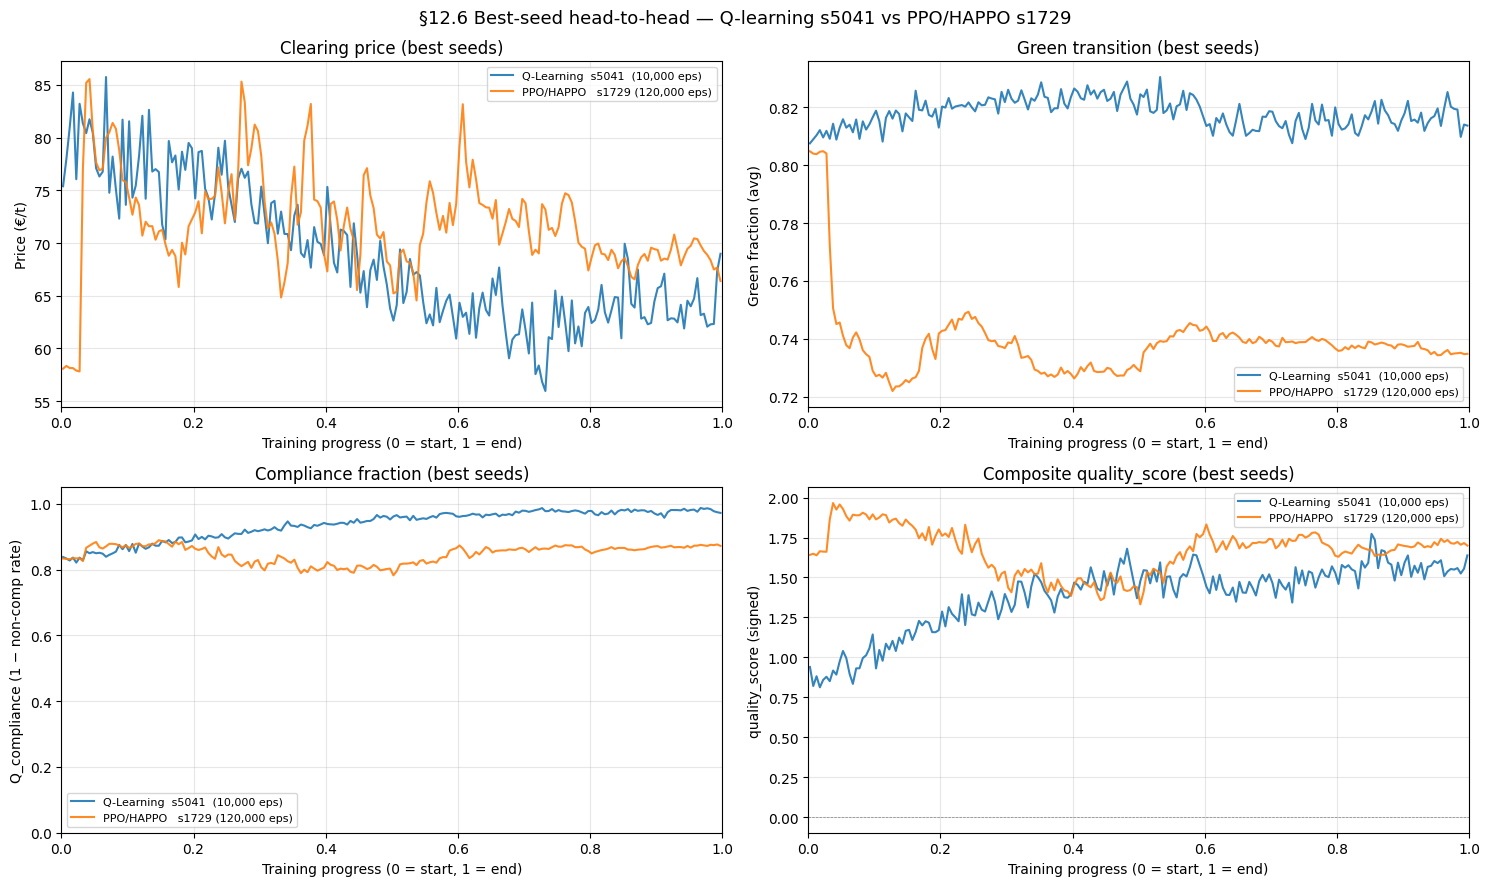

In [94]:
# 12.6  Pick the best seed per algorithm (highest converged quality_score)
#       and replay the §10-style head-to-head on it.
if HAS_SWEEP:
    def _best_seed(stack, frac=0.10):
        """Return (seed, score) for the seed with the highest mean quality_score
        in the last `frac` of episodes; (None, nan) if quality_score is missing."""
        df = stack.get('quality_score')
        if df is None or df.empty:
            return None, float('nan')
        tail = df.tail(max(1, int(len(df) * frac)))
        means = tail.mean(axis=0)
        seed = means.idxmax()
        return int(seed), float(means.loc[seed])

    ql_best_seed,  ql_best_score  = _best_seed(ql_stacks)
    ppo_best_seed, ppo_best_score = _best_seed(ppo_stacks)

    print(f'Top Q-learning seed: {ql_best_seed}  (converged quality_score = {ql_best_score:+.3f})')
    print(f'Top PPO/HAPPO seed:  {ppo_best_seed} (converged quality_score = {ppo_best_score:+.3f})')

    ql_best_df  = load_run_csv(ql_logs[ql_best_seed])   if ql_best_seed  is not None else None
    ppo_best_df = load_run_csv(ppo_logs[ppo_best_seed]) if ppo_best_seed is not None else None

    n_total_cfg = config['companies']['n_agents'] + config['companies'].get('n_bot_agents', 0)

    def _ql_lbl():  return f'Q-Learning  s{ql_best_seed}  ({len(ql_best_df):,} eps)'
    def _ppo_lbl(): return f'PPO/HAPPO   s{ppo_best_seed} ({len(ppo_best_df):,} eps)'

    def _plot_pair(ax, ql_series, ppo_series, ylabel, title):
        if ql_series is not None:
            x, y = _progress_smooth(ql_series)
            if x is not None:
                ax.plot(x, y, label=_ql_lbl(), color='tab:blue', alpha=0.9)
        if ppo_series is not None:
            x, y = _progress_smooth(ppo_series)
            if x is not None:
                ax.plot(x, y, label=_ppo_lbl(), color='tab:orange', alpha=0.9)
        ax.set_xlabel('Training progress (0 = start, 1 = end)')
        ax.set_ylabel(ylabel); ax.set_title(title)
        ax.set_xlim(0.0, 1.0); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    fig, axes = plt.subplots(2, 2, figsize=(15, 9))
    axes = axes.ravel()

    # 1 — Mean clearing price
    px_q  = ql_best_df['ep_mean_clearing_price'] if ql_best_df  is not None and 'ep_mean_clearing_price' in ql_best_df.columns  else (ql_best_df['clearing_price_last']  if ql_best_df  is not None else None)
    px_p  = ppo_best_df['ep_mean_clearing_price'] if ppo_best_df is not None and 'ep_mean_clearing_price' in ppo_best_df.columns else (ppo_best_df['clearing_price_last'] if ppo_best_df is not None else None)
    _plot_pair(axes[0], px_q, px_p, 'Price (€/t)', 'Clearing price (best seeds)')

    # 2 — Mean green fraction across agents
    gf_cols = [f'green_frac_A{i+1}' for i in range(n_agents)]
    gf_q = ql_best_df[[c for c in gf_cols if c in ql_best_df.columns]].apply(pd.to_numeric, errors='coerce').mean(axis=1) if ql_best_df  is not None else None
    gf_p = ppo_best_df[[c for c in gf_cols if c in ppo_best_df.columns]].apply(pd.to_numeric, errors='coerce').mean(axis=1) if ppo_best_df is not None else None
    _plot_pair(axes[1], gf_q, gf_p, 'Green fraction (avg)', 'Green transition (best seeds)')

    # 3 — Compliance fraction (Q_compliance preferred)
    def _compl(df):
        if df is None: return None
        if 'Q_compliance' in df.columns:
            return pd.to_numeric(df['Q_compliance'], errors='coerce')
        return _ppo_compliance(df, n_total_cfg) if 'shortfall_A1' in df.columns or any(c.startswith('compliance_rate_A') for c in df.columns) else None
    _plot_pair(axes[2], _compl(ql_best_df), _compl(ppo_best_df),
               'Q_compliance (1 − non-comp rate)', 'Compliance fraction (best seeds)')
    axes[2].set_ylim(0, 1.05)

    # 4 — Composite quality_score
    qs_q = pd.to_numeric(ql_best_df['quality_score'],  errors='coerce') if ql_best_df  is not None and 'quality_score' in ql_best_df.columns  else None
    qs_p = pd.to_numeric(ppo_best_df['quality_score'], errors='coerce') if ppo_best_df is not None and 'quality_score' in ppo_best_df.columns else None
    _plot_pair(axes[3], qs_q, qs_p, 'quality_score (signed)', 'Composite quality_score (best seeds)')
    axes[3].axhline(0, color='grey', lw=0.5, ls='--')

    plt.suptitle(f'§12.6 Best-seed head-to-head — Q-learning s{ql_best_seed} vs PPO/HAPPO s{ppo_best_seed}',
                 fontsize=13)
    plt.tight_layout(); plt.show()


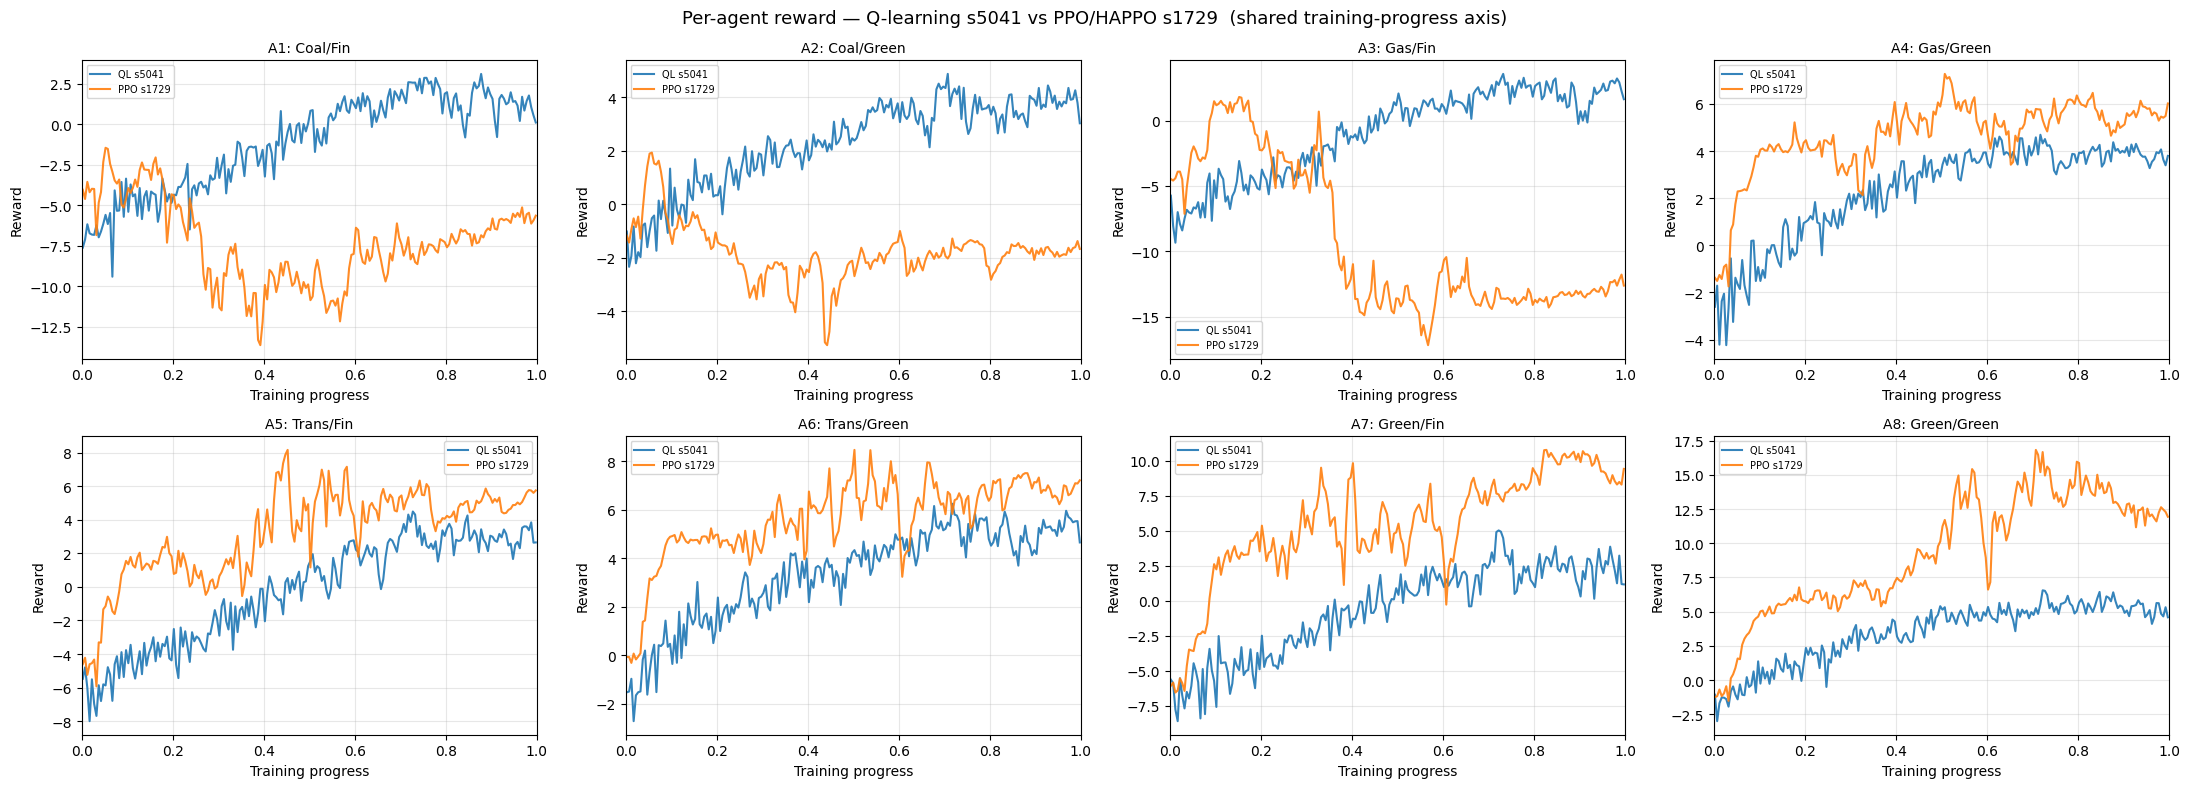

In [95]:
# 12.6b  Per-agent reward, best seed only (matches §10's reward grid)
if HAS_SWEEP and ql_best_df is not None and ppo_best_df is not None:
    fig, axes = plt.subplots(2, 4, figsize=(22, 8))
    fig.suptitle(
        f'Per-agent reward — Q-learning s{ql_best_seed} vs PPO/HAPPO s{ppo_best_seed}  '
        f'(shared training-progress axis)', fontsize=13)
    archetypes_lbl = ['Coal/Fin', 'Coal/Green', 'Gas/Fin', 'Gas/Green',
                      'Trans/Fin', 'Trans/Green', 'Green/Fin', 'Green/Green']
    for i in range(n_agents):
        ax = axes[i // 4, i % 4]
        col = f'reward_A{i+1}'
        if col in ql_best_df.columns:
            x, y = _progress_smooth(ql_best_df[col])
            if x is not None:
                ax.plot(x, y, label=f'QL s{ql_best_seed}', color='tab:blue', alpha=0.9)
        if col in ppo_best_df.columns:
            x, y = _progress_smooth(ppo_best_df[col])
            if x is not None:
                ax.plot(x, y, label=f'PPO s{ppo_best_seed}', color='tab:orange', alpha=0.9)
        ax.set_title(f'A{i+1}: {archetypes_lbl[i]}', fontsize=10)
        ax.set_xlabel('Training progress'); ax.set_ylabel('Reward')
        ax.set_xlim(0.0, 1.0); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()


---

## 13. Takeaways — Sub-RQ 1 lens

**On simulation credibility (Sub-RQ 1).** Q-learning is included here as a *floor*, not a contender. The comparison in §11 sits the tabular baseline directly next to the PPO/HAPPO default sweep on the same metrics, computed from the same `ETSEnvironment`:

* **Convergence (RQ 1.a).** Q-learning typically plateaus within a few thousand episodes — far earlier   than PPO — because its 243-state × 24-action search space saturates fast. PPO's plateau episode in   the same `quality_score` series is the reference for the credibility claim.
* **Reproducibility (RQ 1.b).** Cross-seed std on the converged window is reported in §11.5 for both   algorithms. Cross-seed noise that's small relative to the cross-algorithm gap is what licenses the   rest of the thesis.
* **Recognisability.** A converged Q-learning policy already produces an EU-ETS-shaped trajectory —   positive `quality_score`, anchor-tracking clearing price, plateaued green fraction. That tells us the   *environment* (auction + MSR + warm-start + reward) is the dominant driver of the qualitative   outcome; PPO's gain is in the magnitude of the optima, not their existence.

**Why a tabular baseline is the right baseline.** The discretisation deliberately throws away information that PPO has access to (continuous bid/qty/invest, opponent modelling, terminal-value shaping). Anything PPO does on top of Q-learning is therefore evidence that the extra state and policy expressivity *matters* for this market — which is exactly the design-choice question Sub-RQ 1 is asking.

**Out of scope for this notebook.** Cross-variant sensitivity (LRF / MSR / penalty sweeps) is Sub-RQ 2 territory and lives in the experiments notebook; strategy clustering and the financial-vs-ESG contrast are Sub-RQ 3 in `ets_marl - Default RQ Analysis.ipynb`.


## 13. v8.6.1 Cross-algorithm credit-stress comparison

When both runs (Q-learning and PPO) were produced under v8.6.1+, this section
contrasts the **system-aggregate peak emergency-loan balance** and **peak
carry-forward debt** observed in the converged window. Higher values indicate
that the credibility of the algorithm's compliance behaviour is propped up by
liquidity / debt rather than genuine market participation.

The cell silently no-ops when columns are absent (logs predate 8.6.1).


[s13] Run counts per algorithm: {'PPO': 4}


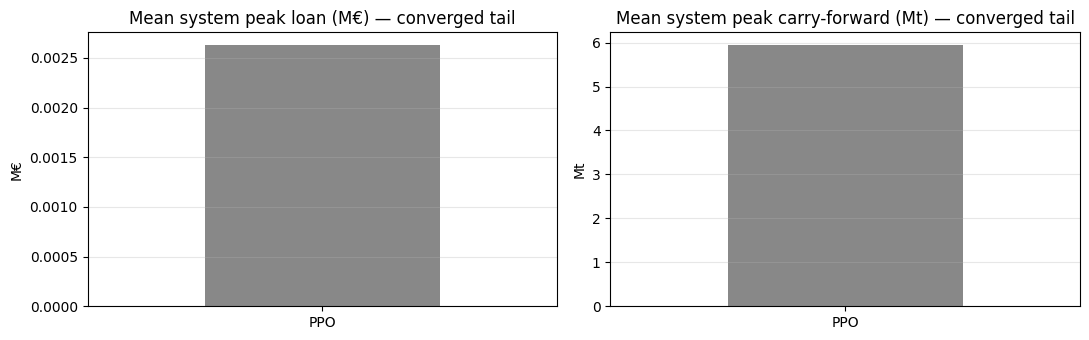

,peak_loan_outstanding,peak_carry_forward
PPO,0.003,5.936


In [93]:
# Section 13 — v8.6.1 credit-stress cross-algo bars.
# Aggregates `peak_loan_outstanding_A{i}` and `peak_carry_forward_A{i}`
# from the per-seed training_log. Backward-compatible.
import numpy as np
import pandas as pd
from src.utils.run_data import load_run_csv, glob_run_logs  # parquet-cached log loader
import matplotlib.pyplot as plt

def _system_peak(ep_df, stub):
    cols = [c for c in ep_df.columns if c.startswith(stub + "_A")]
    if not cols:
        return np.nan
    cut = max(1, len(ep_df) // 2)  # converged tail
    tail = ep_df.iloc[cut:]
    return float(tail[cols].sum(axis=1).mean())

def _collect_logs():
    """Return {label -> list[DataFrame]} pulling from whatever earlier cells produced.

    Preference order (per algo):
      1. {ql,ppo}_train_logs  — list of dataframes (legacy)
      2. {ql,ppo}_logs        — {seed: path} dicts produced in §12.1
      3. {ql,ppo}_df          — single-seed dataframe loaded in §6 / §10
    """
    out = {}
    for label, list_var, dict_var, df_var in [
        ("Q-learning", "ql_train_logs",  "ql_logs",  "ql_df"),
        ("PPO",        "ppo_train_logs", "ppo_logs", "ppo_df"),
    ]:
        # 1. preloaded list of frames
        logs = globals().get(list_var)
        if logs:
            out[label] = list(logs)
            continue
        # 2. seed -> path dict (matched seeds from §12.1)
        path_dict = globals().get(dict_var)
        if isinstance(path_dict, dict) and path_dict:
            out[label] = [load_run_csv(p) for p in path_dict.values()]
            continue
        # 3. single dataframe fallback
        df = globals().get(df_var)
        if isinstance(df, pd.DataFrame) and not df.empty:
            out[label] = [df]
    return out

_logs_by_algo = _collect_logs()

_data = {}
for label, logs in _logs_by_algo.items():
    peak_loans = [_system_peak(l, "peak_loan_outstanding") for l in logs]
    peak_cfs   = [_system_peak(l, "peak_carry_forward")   for l in logs]
    if any(np.isfinite(peak_loans)) or any(np.isfinite(peak_cfs)):
        _data[label] = {
            "peak_loan_outstanding": np.nanmean(peak_loans),
            "peak_carry_forward":    np.nanmean(peak_cfs),
            "n_runs":                len(logs),
        }

if not _logs_by_algo:
    print("[s13] No training logs found in scope — run §6 (loads ql_df) and §10 "
          "(loads ppo_df), or §12.1 (populates ql_logs/ppo_logs).")
elif not _data:
    # Logs exist but neither column family is present.
    have_cols = sorted({c for logs in _logs_by_algo.values() for l in logs for c in l.columns
                        if c.startswith(("peak_loan_outstanding_A", "peak_carry_forward_A"))})
    print("[s13] Cross-algo credit-stress columns missing — pre-8.6.1 logs.")
    print(f"      Loaded {sum(len(v) for v in _logs_by_algo.values())} run(s) "
          f"across {list(_logs_by_algo)}; matching credit-stress cols: {have_cols or 'none'}.")
else:
    df = pd.DataFrame({k: {kk: vv for kk, vv in v.items() if kk != 'n_runs'}
                       for k, v in _data.items()}).T
    n_runs = {k: v['n_runs'] for k, v in _data.items()}
    print(f"[s13] Run counts per algorithm: {n_runs}")
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
    df["peak_loan_outstanding"].plot(kind="bar", ax=axes[0], color=["#888", "#1f77b4"])
    axes[0].set_title("Mean system peak loan (M€) — converged tail")
    axes[0].set_ylabel("M€"); axes[0].grid(alpha=0.3, axis="y")
    df["peak_carry_forward"].plot(kind="bar", ax=axes[1], color=["#888", "#1f77b4"])
    axes[1].set_title("Mean system peak carry-forward (Mt) — converged tail")
    axes[1].set_ylabel("Mt"); axes[1].grid(alpha=0.3, axis="y")
    for ax in axes:
        ax.tick_params(axis="x", rotation=0)
    plt.tight_layout(); plt.show()
    display(df.round(3))


---

## 14. Classic D / A panels  (ported from `Full Run & Analysis` and `Sweep Analysis`)

These are the same six-panel D1 / D2 / A3 / A7 boards used elsewhere in the
project, restricted to the columns Q-learning logs (no actor/critic loss
panels — Q-learning has no actor/critic). Run after §6 has populated
``ql_df`` (training log) and after §15 below loads the year log.

```
D1 — Training Convergence (rewards, ε-decay, quality_score)
D2 — Carbon Price & Auction Supply (clearing price, TNAC, MSR)
A3 — Green Transition Strategy (green frac per agent, investment timing)
A7 — Convergence Quality Metric (the same anchor-invariant Q the PPO trainer logs)
```


In [80]:
# Load the year log so D2 / A3 can plot per-year trajectories.
import os, glob
yr_pattern = os.path.join(results_dir, f"ql_year_log_s{ACTIVE_SEED}.csv")
yr_candidates = glob.glob(yr_pattern) or glob_run_logs(
    os.path.join(results_dir, "ql_year_log_s*.csv"))
if yr_candidates:
    yr_path = yr_candidates[0]
    yr_df = load_run_csv(yr_path)
    # Restrict to a "converged window" — the last 10% of episodes.
    converged_eps = yr_df['episode'].unique()
    converged_eps = converged_eps[max(0, int(len(converged_eps) * 0.9)):]
    recent_yr = yr_df[yr_df['episode'].isin(converged_eps)].copy()
    print(f'Year log loaded: {yr_path}  ({len(yr_df):,} rows, '
          f'{len(converged_eps)} converged episodes).')
    HAS_YR_LOG = True
else:
    print('Year log not found — D2/A3 will be skipped. '
          f'Expected: {yr_pattern}')
    HAS_YR_LOG = False
    yr_df = None; recent_yr = None

ROLL = max(1, len(ql_df) // 50)
agent_colors = plt.cm.tab10(np.linspace(0, 1, n_agents))
agent_labels = [f'A{i+1}' for i in range(n_agents)]


Year log loaded: results/qlearning\ql_year_log_s8191.csv  (120,000 rows, 1000 converged episodes).


### 14.1 D1 — Training Convergence

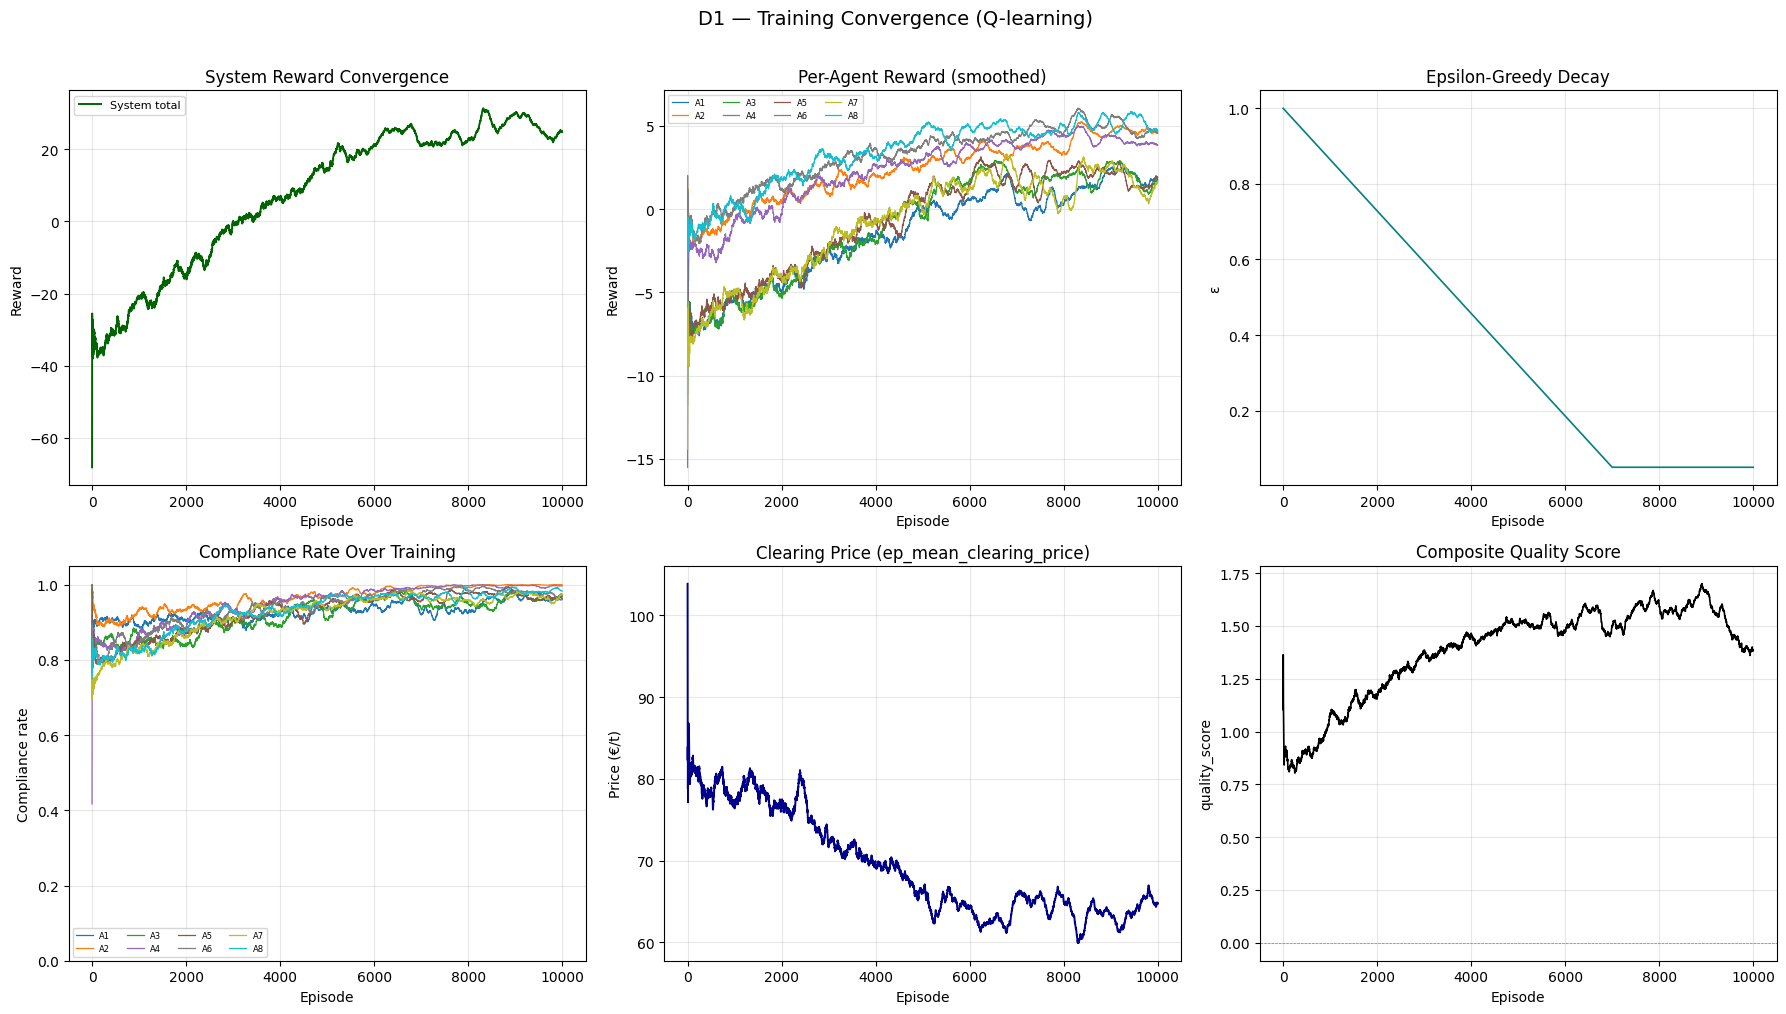

In [88]:
# D1 — Training Convergence (rewards + ε-decay + Q over training)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

reward_cols_total = [f'reward_A{i+1}' for i in range(n_agents) if f'reward_A{i+1}' in ql_df.columns]

# 1 — System reward
ax = axes[0, 0]
if reward_cols_total:
    total_rew = ql_df[reward_cols_total].sum(axis=1)
    ax.plot(ql_df['episode'], total_rew.rolling(ROLL, min_periods=1).mean(),
            color='darkgreen', lw=1.4, label='System total')
    ax.set_title('System Reward Convergence')
ax.set_xlabel('Episode'); ax.set_ylabel('Reward'); ax.grid(True, alpha=0.3); ax.legend(fontsize=8)

# 2 — Per-agent reward
ax = axes[0, 1]
for i in range(n_agents):
    col = f'reward_A{i+1}'
    if col in ql_df.columns:
        ax.plot(ql_df['episode'], ql_df[col].rolling(ROLL, min_periods=1).mean(),
                color=agent_colors[i], lw=0.9, label=f'A{i+1}')
ax.set_xlabel('Episode'); ax.set_ylabel('Reward')
ax.set_title('Per-Agent Reward (smoothed)')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 3 — Epsilon decay (Q-learning's exploration schedule)
ax = axes[0, 2]
if 'epsilon' in ql_df.columns:
    ax.plot(ql_df['episode'], ql_df['epsilon'], color='teal', lw=1.2)
    ax.set_xlabel('Episode'); ax.set_ylabel('ε')
    ax.set_title('Epsilon-Greedy Decay')
ax.grid(True, alpha=0.3)

# 4 — Compliance rate per agent over training
ax = axes[1, 0]
for i in range(n_agents):
    col = f'compliance_rate_A{i+1}'
    if col in ql_df.columns:
        ax.plot(ql_df['episode'], ql_df[col].rolling(ROLL, min_periods=1).mean(),
                color=agent_colors[i], lw=0.9, label=f'A{i+1}')
ax.set_ylim(0, 1.05); ax.set_xlabel('Episode'); ax.set_ylabel('Compliance rate')
ax.set_title('Compliance Rate Over Training')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 5 — Mean clearing price over training
ax = axes[1, 1]
price_col = 'ep_mean_clearing_price' if 'ep_mean_clearing_price' in ql_df.columns else 'clearing_price_last'
if price_col in ql_df.columns:
    ax.plot(ql_df['episode'], ql_df[price_col].rolling(ROLL, min_periods=1).mean(),
            color='darkblue', lw=1.4)
    ax.set_xlabel('Episode'); ax.set_ylabel('Price (€/t)')
    ax.set_title(f'Clearing Price ({price_col})')
ax.grid(True, alpha=0.3)

# 6 — Composite quality_score
ax = axes[1, 2]
if 'quality_score' in ql_df.columns:
    qs = pd.to_numeric(ql_df['quality_score'], errors='coerce')
    ax.plot(ql_df['episode'], qs.rolling(ROLL, min_periods=1).mean(),
            color='black', lw=1.2)
    ax.axhline(0, color='grey', lw=0.5, ls='--')
    ax.set_xlabel('Episode'); ax.set_ylabel('quality_score')
    ax.set_title('Composite Quality Score')
ax.grid(True, alpha=0.3)

plt.suptitle('D1 — Training Convergence (Q-learning)', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()


### 14.2 D2 — Carbon Price & Auction Supply

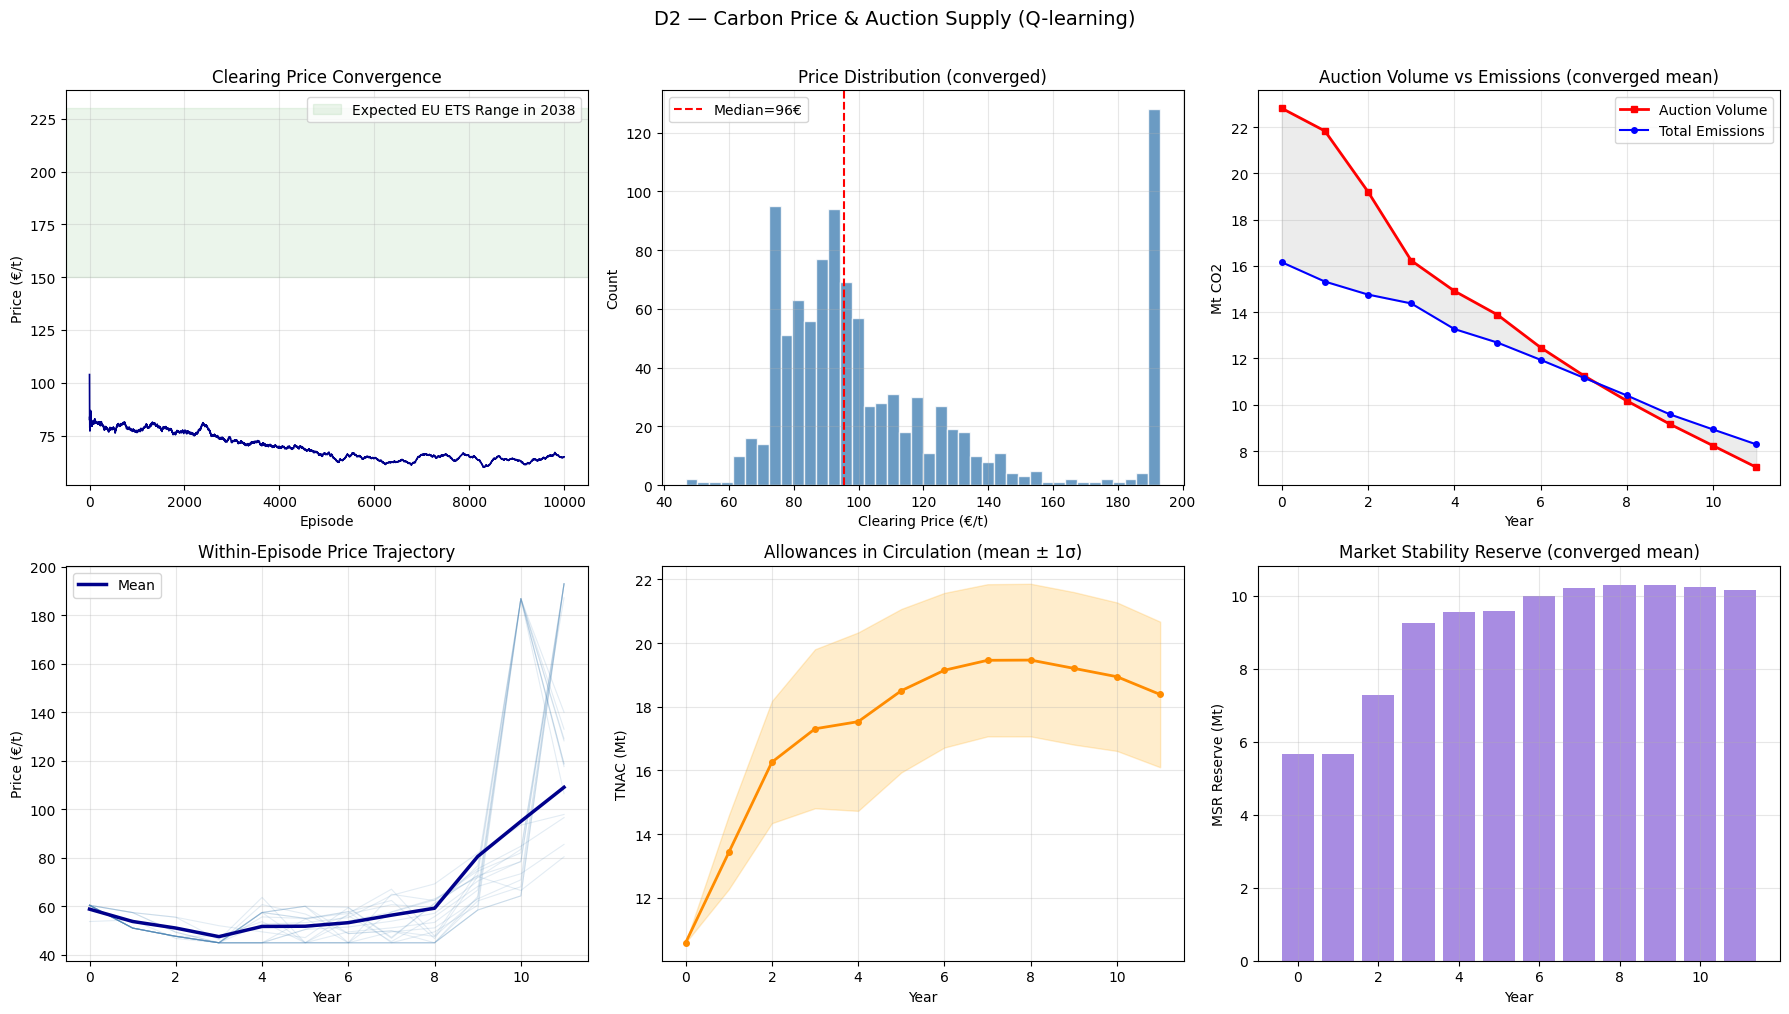

In [89]:
# D2 — Carbon Price & Auction Supply (requires year log)
if HAS_YR_LOG:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # 1 — Clearing price over training (episode-level)
    ax = axes[0, 0]
    px_col = 'ep_mean_clearing_price' if 'ep_mean_clearing_price' in ql_df.columns else 'clearing_price_last'
    ax.plot(ql_df['episode'], ql_df[px_col].rolling(ROLL, min_periods=1).mean(),
            color='darkblue', lw=1.2)
    ax.axhspan(150, 230, alpha=0.08, color='green', label='Expected EU ETS Range in 2038')
    ax.set_xlabel('Episode'); ax.set_ylabel('Price (€/t)')
    ax.set_title('Clearing Price Convergence'); ax.legend(); ax.grid(True, alpha=0.3)

    # 2 — Price distribution (converged)
    ax = axes[0, 1]
    prices_conv = recent_yr.groupby('episode')['clearing_price'].last()
    ax.hist(prices_conv, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(prices_conv.median(), color='red', ls='--', label=f'Median={prices_conv.median():.0f}€')
    ax.set_xlabel('Clearing Price (€/t)'); ax.set_ylabel('Count')
    ax.set_title('Price Distribution (converged)'); ax.legend(); ax.grid(True, alpha=0.3)

    # 3 — Auctioned volume vs total emissions
    ax = axes[0, 2]
    auction_by_yr = recent_yr.groupby('year')['auction_volume'].mean()
    emis_cols = sorted([c for c in recent_yr.columns if c.startswith('emissions_A')],
                       key=lambda c: int(c.split('_A')[1]))
    if emis_cols:
        emis_by_yr = recent_yr[emis_cols].sum(axis=1).groupby(recent_yr['year']).mean()
        ax.plot(auction_by_yr.index, auction_by_yr.values, 'r-s', ms=5, label='Auction Volume', lw=2)
        ax.plot(emis_by_yr.index, emis_by_yr.values, 'b-o', ms=4, label='Total Emissions', lw=1.5)
        ax.fill_between(auction_by_yr.index, auction_by_yr.values, emis_by_yr.values,
                        alpha=0.15, color='gray')
    ax.set_xlabel('Year'); ax.set_ylabel('Mt CO2')
    ax.set_title('Auction Volume vs Emissions (converged mean)')
    ax.legend(); ax.grid(True, alpha=0.3)

    # 4 — Within-episode price trajectory
    ax = axes[1, 0]
    sample_eps = sorted(recent_yr['episode'].unique()[-20:])
    for ep in sample_eps:
        ep_data = recent_yr[recent_yr['episode'] == ep]
        ax.plot(ep_data['year'], ep_data['clearing_price'], color='steelblue', alpha=0.15, lw=0.8)
    mean_px_yr = recent_yr.groupby('year')['clearing_price'].mean()
    ax.plot(mean_px_yr.index, mean_px_yr.values, 'darkblue', lw=2.5, label='Mean')
    ax.set_xlabel('Year'); ax.set_ylabel('Price (€/t)')
    ax.set_title('Within-Episode Price Trajectory'); ax.legend(); ax.grid(True, alpha=0.3)

    # 5 — TNAC over years
    ax = axes[1, 1]
    if 'tnac' in recent_yr.columns:
        tnac_yr = recent_yr.groupby('year')['tnac'].agg(['mean', 'std']).fillna(0.0)
        ax.plot(tnac_yr.index, tnac_yr['mean'], 'darkorange', lw=2, marker='o', ms=4)
        ax.fill_between(tnac_yr.index, tnac_yr['mean'] - tnac_yr['std'],
                        tnac_yr['mean'] + tnac_yr['std'], alpha=0.2, color='orange')
        ax.set_xlabel('Year'); ax.set_ylabel('TNAC (Mt)')
        ax.set_title('Allowances in Circulation (mean ± 1σ)')
    ax.grid(True, alpha=0.3)

    # 6 — MSR reserve
    ax = axes[1, 2]
    if 'msr_reserve' in recent_yr.columns:
        msr_yr = recent_yr.groupby('year')['msr_reserve'].mean()
        ax.bar(msr_yr.index, msr_yr.values, color='mediumpurple', alpha=0.8)
        ax.set_xlabel('Year'); ax.set_ylabel('MSR Reserve (Mt)')
        ax.set_title('Market Stability Reserve (converged mean)')
    ax.grid(True, alpha=0.3)

    plt.suptitle('D2 — Carbon Price & Auction Supply (Q-learning)', fontsize=14, y=1.01)
    plt.tight_layout(); plt.show()
else:
    print('Skipping D2 — year log unavailable.')


### 14.3 A3 — Green Transition Strategy

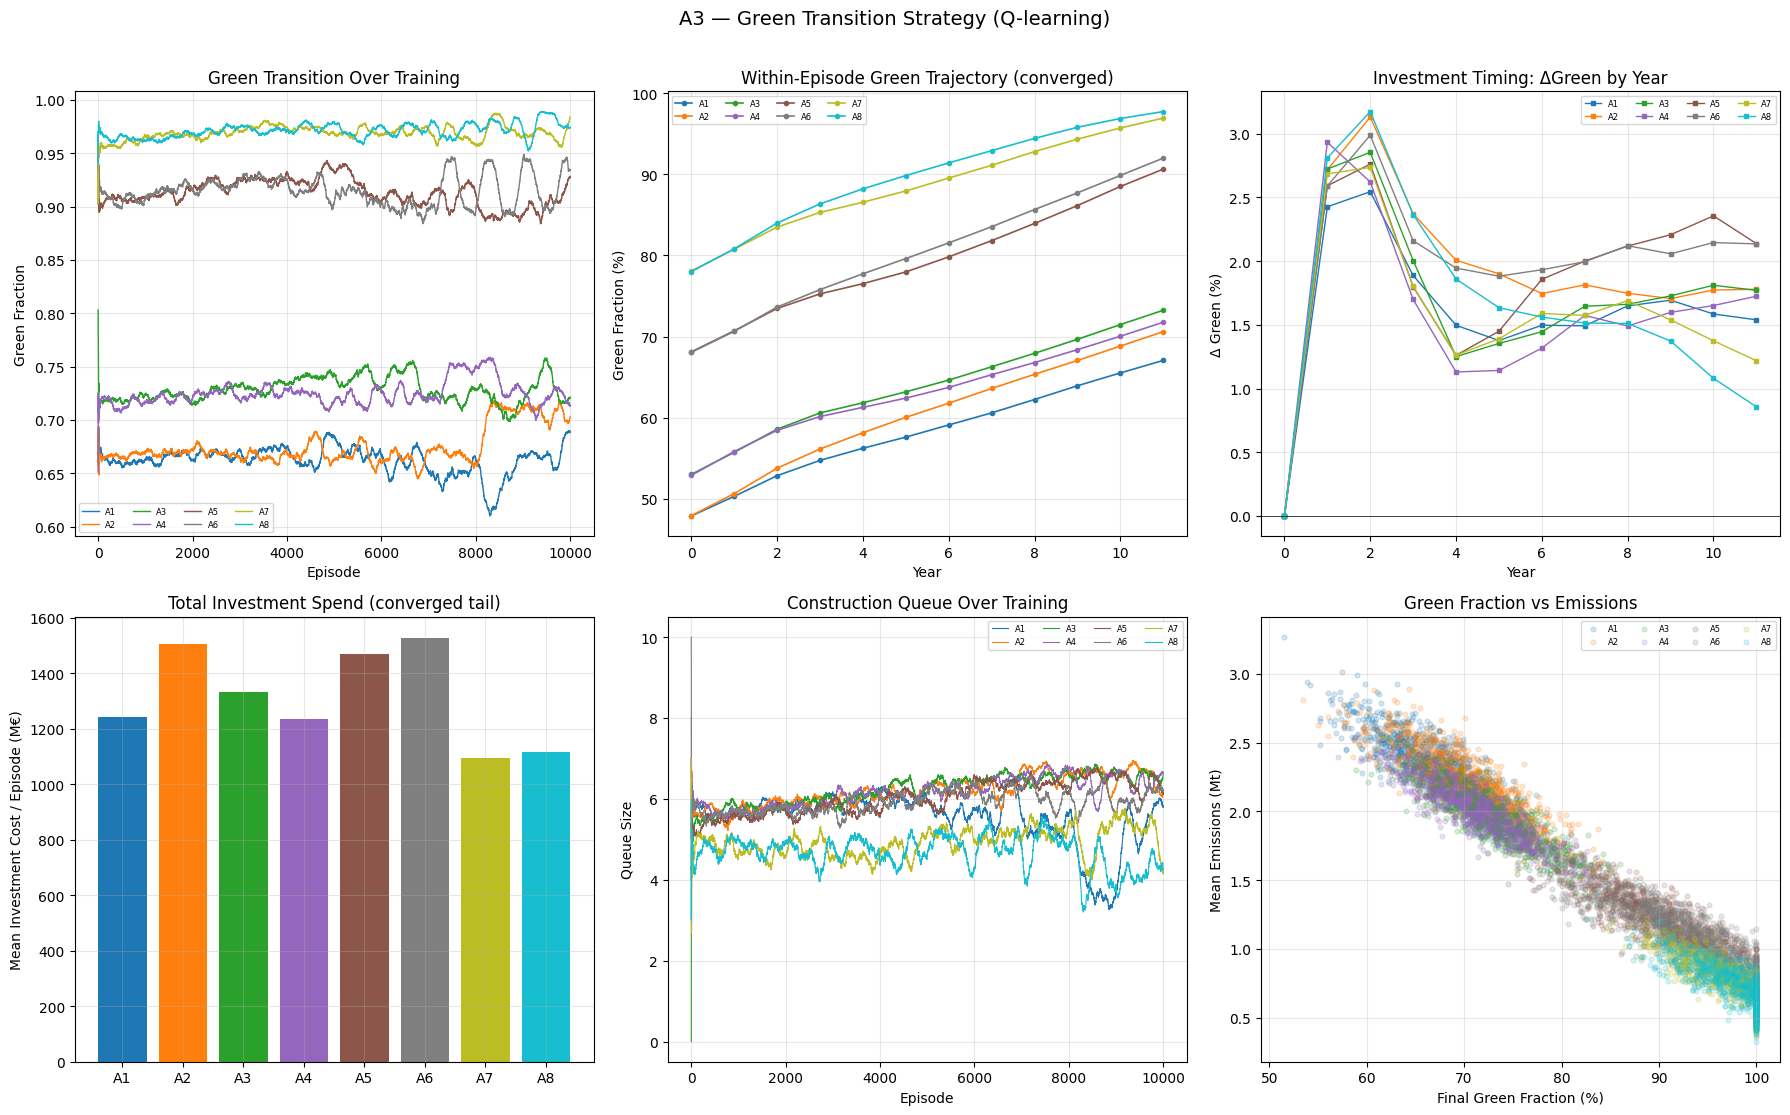

In [90]:
# A3 — Green Transition Strategy (per-agent green fraction over time)
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# 1 — Green fraction over training (episode-level)
ax = axes[0, 0]
for i in range(n_agents):
    col = f'green_frac_A{i+1}'
    if col in ql_df.columns:
        ax.plot(ql_df['episode'], ql_df[col].rolling(ROLL, min_periods=1).mean(),
                color=agent_colors[i], lw=1, label=f'A{i+1}')
ax.set_xlabel('Episode'); ax.set_ylabel('Green Fraction')
ax.set_title('Green Transition Over Training')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 2 — Green fraction by year within episode (converged) — needs year log
ax = axes[0, 1]
if HAS_YR_LOG:
    for i in range(n_agents):
        col = f'green_frac_A{i+1}'
        if col in recent_yr.columns:
            gf_yr = recent_yr.groupby('year')[col].mean()
            ax.plot(gf_yr.index, gf_yr.values * 100, color=agent_colors[i], marker='o', ms=3,
                    lw=1.2, label=f'A{i+1}')
    ax.set_xlabel('Year'); ax.set_ylabel('Green Fraction (%)')
    ax.set_title('Within-Episode Green Trajectory (converged)')
    ax.legend(fontsize=6, ncol=4)
ax.grid(True, alpha=0.3)

# 3 — Delta green by year (when do agents invest?)
ax = axes[0, 2]
if HAS_YR_LOG:
    for i in range(n_agents):
        col = f'delta_green_A{i+1}'
        if col in recent_yr.columns:
            dg_yr = recent_yr.groupby('year')[col].mean() * 100
            ax.plot(dg_yr.index, dg_yr.values, color=agent_colors[i], marker='s', ms=3,
                    lw=1, label=f'A{i+1}')
    ax.axhline(0, color='black', ls='-', lw=0.5)
    ax.set_xlabel('Year'); ax.set_ylabel('Δ Green (%)')
    ax.set_title('Investment Timing: ΔGreen by Year')
    ax.legend(fontsize=6, ncol=4)
ax.grid(True, alpha=0.3)

# 4 — Investment cost per agent (converged)
ax = axes[1, 0]
inv_cols_present = [f'invest_cost_A{i+1}' for i in range(n_agents)
                    if f'invest_cost_A{i+1}' in ql_df.columns]
if inv_cols_present:
    tail = ql_df.tail(max(1, len(ql_df) // 10))
    inv_means = [tail[c].mean() for c in inv_cols_present]
    ax.bar([f'A{i+1}' for i in range(len(inv_cols_present))], inv_means,
           color=agent_colors[:len(inv_cols_present)])
    ax.set_ylabel('Mean Investment Cost / Episode (M€)')
    ax.set_title('Total Investment Spend (converged tail)')
ax.grid(True, alpha=0.3)

# 5 — Construction queue over training
ax = axes[1, 1]
for i in range(n_agents):
    col = f'queue_size_A{i+1}'
    if col in ql_df.columns:
        ax.plot(ql_df['episode'], ql_df[col].rolling(ROLL, min_periods=1).mean(),
                color=agent_colors[i], lw=0.8, label=f'A{i+1}')
ax.set_xlabel('Episode'); ax.set_ylabel('Queue Size')
ax.set_title('Construction Queue Over Training')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 6 — Green fraction vs emissions (converged)
ax = axes[1, 2]
if HAS_YR_LOG:
    for i in range(n_agents):
        gcol = f'green_frac_A{i+1}'; ecol = f'emissions_A{i+1}'
        if gcol in recent_yr.columns and ecol in recent_yr.columns:
            gf = recent_yr.groupby('episode')[gcol].last()
            em = recent_yr.groupby('episode')[ecol].mean()
            ax.scatter(gf * 100, em, alpha=0.18, s=12, color=agent_colors[i], label=f'A{i+1}')
    ax.set_xlabel('Final Green Fraction (%)'); ax.set_ylabel('Mean Emissions (Mt)')
    ax.set_title('Green Fraction vs Emissions')
    ax.legend(fontsize=6, ncol=4)
ax.grid(True, alpha=0.3)

plt.suptitle('A3 — Green Transition Strategy (Q-learning)', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()


### 14.4 A7 — Convergence Quality Metric

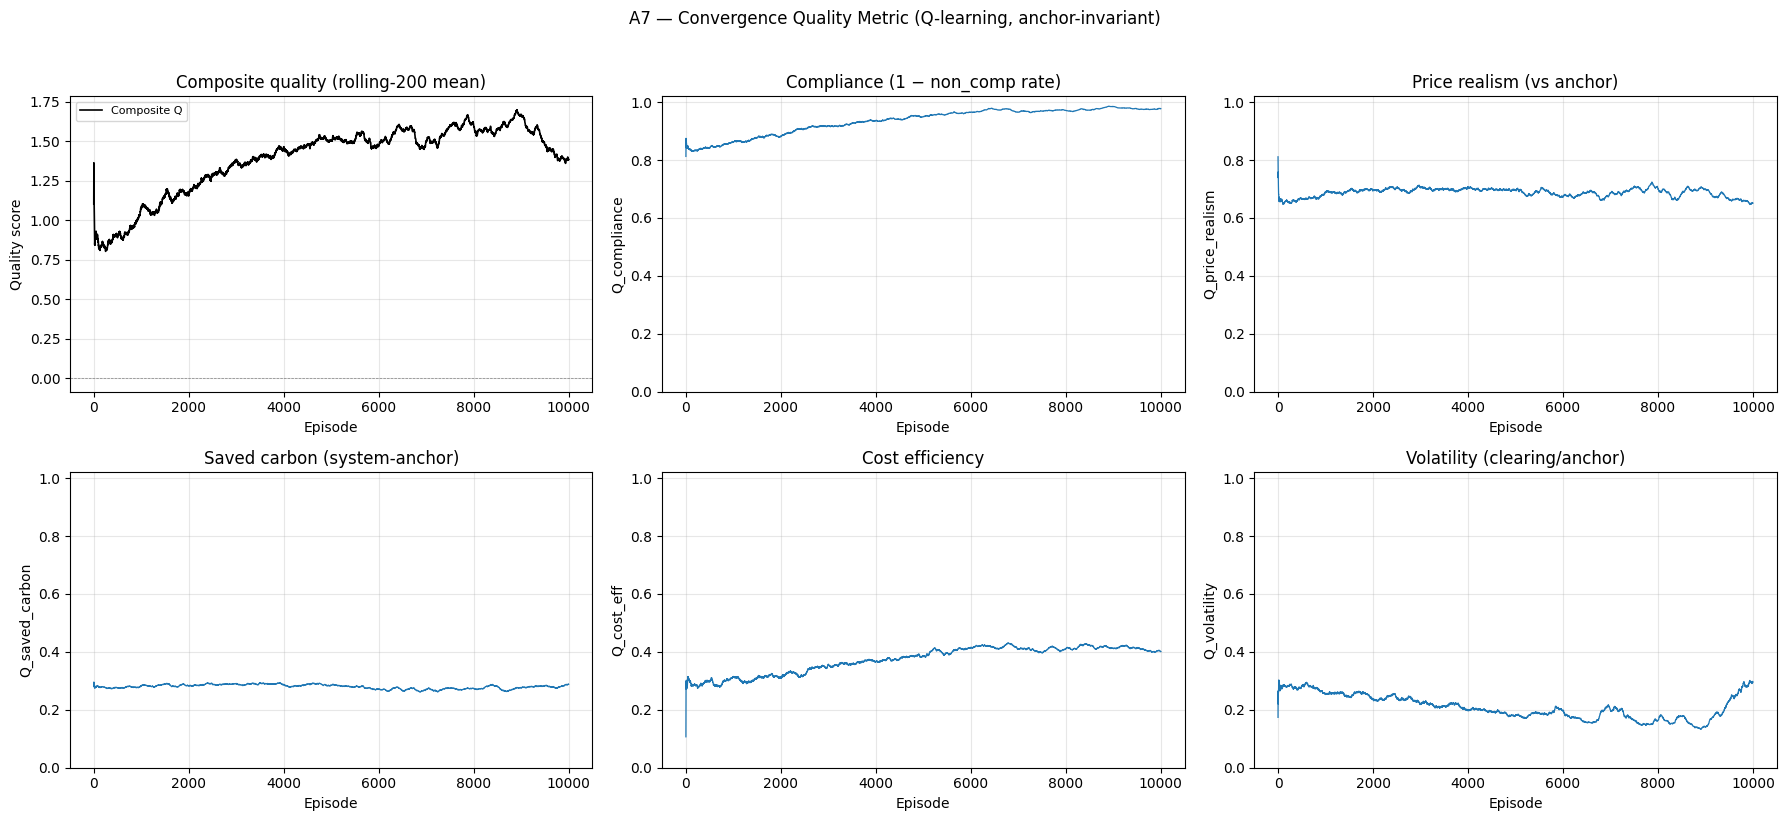


Tail (last 10% of episodes) — quality summary:
      quality_score  Q_compliance  Q_price_realism  Q_saved_carbon  \
mean         1.4633        0.9770           0.6647          0.2816   
std          0.3105        0.0189           0.0611          0.0402   

      Q_cost_eff  Q_volatility  
mean      0.4096        0.2430  
std       0.0441        0.1316  


In [91]:
# A7 — Convergence Quality Metric (anchor-invariant; same metric the PPO trainer logs)
q_components = ['Q_compliance', 'Q_price_realism', 'Q_saved_carbon', 'Q_cost_eff', 'Q_volatility']
q_columns = ['quality_score'] + q_components

if not all(c in ql_df.columns for c in q_columns):
    missing = [c for c in q_columns if c not in ql_df.columns]
    print(f'Quality metric columns not present in training_log: {missing}. '
          'Re-run training with the latest src/train_qlearning.py to populate them.')
else:
    fig, axes = plt.subplots(2, 3, figsize=(18, 8))
    qx = ql_df['episode']

    ax = axes[0, 0]
    ax.plot(qx, pd.to_numeric(ql_df['quality_score'], errors='coerce').rolling(ROLL, min_periods=1).mean(),
            color='black', lw=1.2, label='Composite Q')
    ax.set_xlabel('Episode'); ax.set_ylabel('Quality score')
    ax.set_title(f'Composite quality (rolling-{ROLL} mean)')
    ax.axhline(0, color='grey', lw=0.5, ls='--')
    ax.grid(True, alpha=0.3); ax.legend(fontsize=8)

    component_axes = [axes[0, 1], axes[0, 2], axes[1, 0], axes[1, 1], axes[1, 2]]
    component_titles = {
        'Q_compliance':    'Compliance (1 − non_comp rate)',
        'Q_price_realism': 'Price realism (vs anchor)',
        'Q_saved_carbon':  'Saved carbon (system-anchor)',
        'Q_cost_eff':      'Cost efficiency',
        'Q_volatility':    'Volatility (clearing/anchor)',
    }
    for ax, comp in zip(component_axes, q_components):
        s = pd.to_numeric(ql_df[comp], errors='coerce').rolling(ROLL, min_periods=1).mean()
        ax.plot(qx, s, lw=0.9)
        ax.set_xlabel('Episode'); ax.set_ylabel(comp)
        ax.set_title(component_titles[comp])
        ax.set_ylim(0, 1.02); ax.grid(True, alpha=0.3)

    plt.suptitle('A7 — Convergence Quality Metric (Q-learning, anchor-invariant)', y=1.02)
    plt.tight_layout(); plt.show()

    tail = ql_df.tail(max(1, len(ql_df) // 10))
    summary = tail[q_columns].apply(pd.to_numeric, errors='coerce').agg(['mean', 'std']).round(4)
    print('\nTail (last 10% of episodes) — quality summary:')
    print(summary)
